# Import

In [325]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm  
from data_fitting.module_fitzcu import *
from data_fitting.abcd_rf_fit import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp
from yamltool import yml_comment

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [326]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.7"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK running on ZCU216, software version 0.2.342

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2,

In [327]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str, yoko:str=None) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1
    if yoko is not None:
        return os.path.join(save_path, f"{exp_name}_{yoko:.2f}mA")
    else:
        return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2D3QFF1'

# Connect yoko

In [4]:
# client = Labber.connectToServer('localhost', timeout=86400)
# yoko_connect='0x0B21::0x0039::91T810992'
# yoko_global = client.connectToInstrument(
#     'Yokogawa GS200 DC Source', dict(
#         interface='USB', address=(yoko_connect))
# )
# yoko_global_cfg = {
#     'Current - Sweep rate': 50e-6,
#     'Function': 'Current',
#     'Range (I)': '10 mA',
#     'Output': True,
# }
# yoko_global.setValue(sQuant='Output', value=True)


In [5]:
# Yoko_current = -0.414 # [mA]
# yoko_global.setValue(sQuant='Current', value=Yoko_current*1e-3, rate=20e-6)

In [329]:
Yoko_current=None

# System config

In [328]:
r1 = 5350
r2 = 6058
r3 = 7447
r4 = 5795.62
r5 = 5917.51
r6 = 6051.89

r = [r1, r2, r3, r4, r5, r6]

In [191]:
q1, q2, q3, q4, q5, q6 = [5, 4, 2, 11, 9, 3]
q = [q1, q2, q3, q4, q5, q6]

In [330]:
qubit_idx = 2
config = {
    ## Channel Params. ##
    'res_ch': 0,
    'ro_ch': 0,
    'qubit_ch': q[qubit_idx],

    ## Res Pulse Params. ##
    'f_res': r[qubit_idx], # [MHz]
    'res_len': 10, # [us]
    'res_phase': 0, # [deg]
    'res_gain': 0, # [DAC units]
    'res_sigma':0.004,
    ## Readout Params. ##
    'trig_time': 0.49, # [us]
    'ro_len': 10, # [us]
    'relax_delay': 50, # [us]
    'thresholds': None,

    ## Qubit Params. ##
    'qb_pulse_style': 'arb',
    'f_ge': 348.22, # [MHz]
    'nqz':2,
    'qubit_gain': 1,
    'probe_len': 5, # [us]
    'flat_top_len':2, # [us]
    "pi_gain":  0.001, # [DAC units]
    "pi2_gain": 0.001, # [DAC units]
    'qubit_phase': 0,
    'sigma': 0.1/5,
    'ramsey_freq': 3, # [MHz]
     }

# TOF

In [12]:
class LoopbackProgram(AveragerProgramV2):
    
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']

        if soccfg['gens'][res_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=res_ch, nqz=2, mixer_freq=cfg['f_res'], ro_ch=ro_ch)
        else:
            self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_ch)
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'])
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=0,
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.delay_auto(0.5)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=0, ddr4=False)


run_cfg = {**config}
run_cfg['res_len'] = 0.4
run_cfg['ro_len'] = 1
run_cfg['res_gain'] = 1
run_cfg['f_res'] = 5000
run_cfg['res_sigma'] = 0.01

###################
# Run the Program
###################
pyavg = 500

prog =LoopbackProgram(soccfg, reps=1, final_delay=1, cfg=run_cfg)
iq_list = prog.acquire_decimated(soc, rounds=pyavg)
t = prog.get_time_axis(ro_index=0)


ro_ch was defined for generator 0, but it's not multiplexed and doesn't have a mixer, so it will do nothing


  0%|          | 0/500 [00:00<?, ?it/s]

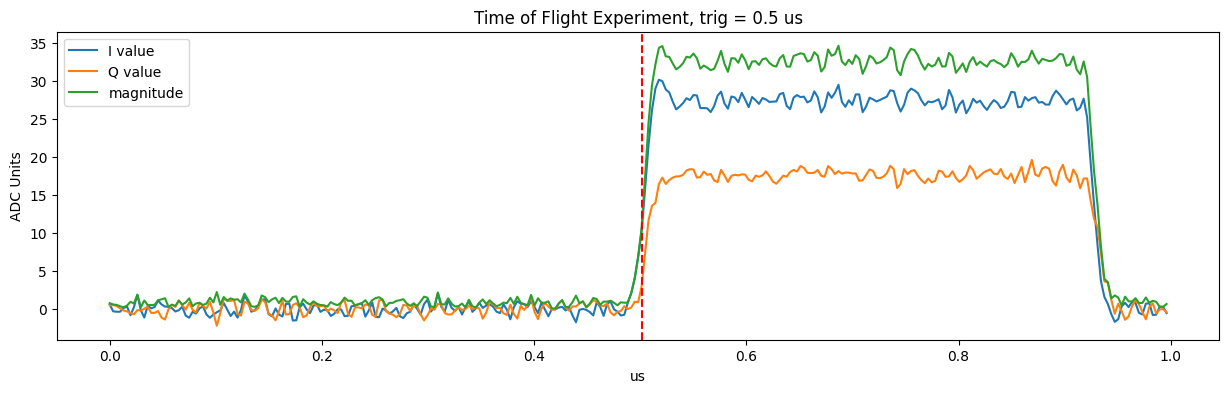

In [13]:
# Plot results.
mean=np.mean(np.abs(iq_list[0].dot([1,1j])))


plt.figure(figsize=(15,4))
plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("ADC Units")
plt.xlabel("us")

######## SET THIS VALUE AS YOUR config['trig_time'] #########
# plt.axvline(0.5, c='r') 
plt.axvline(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 0.7*mean)], c='r', ls='--')
plt.title(f'Time of Flight Experiment, trig = {round(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 0.7*mean)],2)} us')
config['trig_time'] = 0.45#round(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 0.7*mean)],2)

# Resonator Spectroscopy

In [331]:
## Using the Dynamically Configured Readout Channel ##
class SingleToneSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'])
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [334]:
qubit_idx = 2
center = r[qubit_idx]

START_FREQ = center - 10 # [MHz]
STOP_FREQ =  center + 10 # [MHz]

# START_FREQ = 7000 # [MHz]
# STOP_FREQ =  7600 # [MHz]
STEPS = 201

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.4
}
run_cfg = {**config, **exp_cfg}


  0%|          | 0/10 [00:00<?, ?it/s]

{'Fres(GHz)': 7447114762.29,
 'Qi': 44262,
 'Ql': 3720,
 'absQc': 4062,
 'κ(MHz)': 2.0}


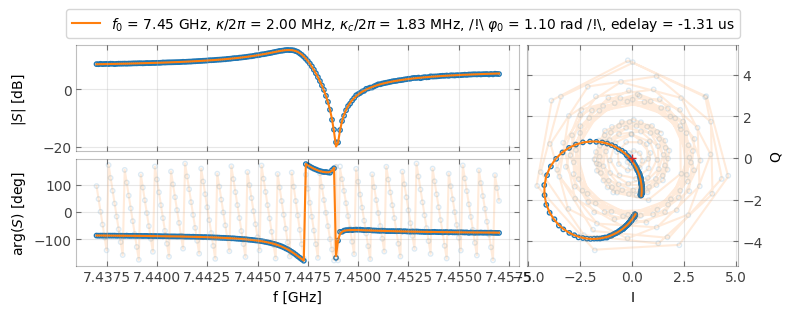

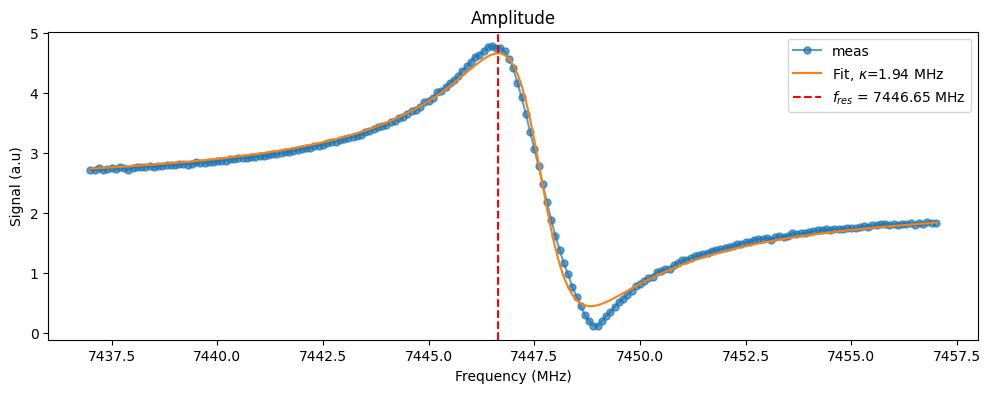

In [335]:
pyavg = 10

prog = SingleToneSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
res_onetone = (iq_list[0][0].dot([1,1j]))

fit = resonator_circlefit(freqs, res_onetone, solve_type='hm')
f = resonator_analyze(freqs, res_onetone)
f_res = round(fit[0]/1e6, 3)
config['f_res'] = f_res

In [34]:
data_path = data_path
exp_name = f"R{qubit_idx+1} resonator spec"


file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  

        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  res_onetone},
        comment=(f'f_res = {f_res:.3f} MHz\
                 \nYoko = {Yoko_current} mA'),
        tag= 'OneTone'
)

# Resonator Onetone Flux

In [167]:
from YOKOGS200 import YOKOGS200
import pyvisa 
rm = pyvisa.ResourceManager()
yoko_connect='USB0::0x0B21::0x0039::90ZB35282::INSTR'
yoko = YOKOGS200(yoko_connect, rm)
yoko.GetCurrent()
yoko.OutputOff()

In [129]:
# #0.414 mA
# START_FREQ = r[qubit_idx]-15 # [MHz]
# STOP_FREQ = r[qubit_idx]+15 # [MHz]
# STEPS = 101

# Start_flux = 0.5 # [mA]
# Stop_flux = -0.5 # [mA]
# Steps_flux = 51

# pyavg = 20


# ### Flux array ###
# flux = np.linspace(Start_flux, Stop_flux, Steps_flux)*1e-3
# exp_cfg = {
#     'steps': STEPS, # Number of sweep points
#     'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
#     'res_gain': 0.2
# }
# run_cfg = {**config, **exp_cfg}

# z=[]
# for i in tqdm(flux):
#     yoko.SetCurrent(i)
#     prog = SingleToneSpectroscopyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
#     iq_list = prog.acquire(soc, rounds=pyavg, progress=False)
#     z.append(iq_list[0][0].dot([1,1j]))

# freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)

# avg_abs, avg_angle = np.abs(z), np.angle(z)

# fig, axes = plt.subplots(1, 2, figsize=(15,4))
# fig.suptitle('Resonator Flux Spectrum')
# for i, d in enumerate([avg_abs, avg_angle]):
#     if i==0:
#         pcm = axes[i].pcolormesh(flux*1e3, freqs, d.T, shading="Auto")
#     else:
#         pcm = axes[i].pcolormesh(flux*1e3, freqs, np.unwrap(d).T, shading="Auto", cmap="bwr")
#     axes[i].set_ylabel("Frequence (MHz)")
#     axes[i].set_xlabel("Current (mA)")
#     axes[i].set_title("Amp" if i ==0  else "IQ phase (rad)")
#     plt.colorbar(pcm, ax=axes[i])

In [ ]:
# yoko.SetCurrent(0)

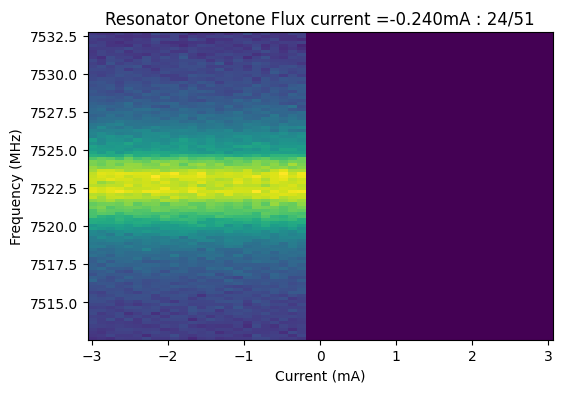

KeyboardInterrupt: 

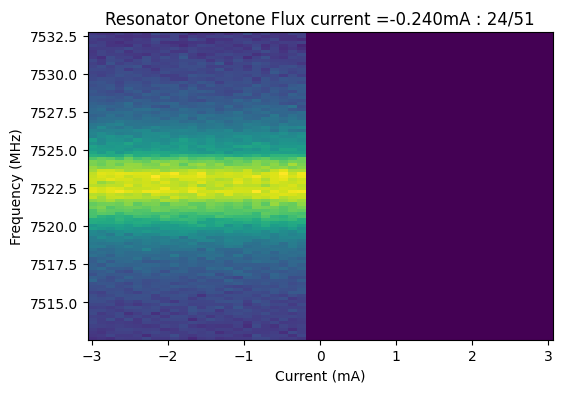

In [153]:

from IPython.display import display, clear_output

START_FREQ = r[qubit_idx]- 10 # [MHz]
STOP_FREQ = r[qubit_idx] + 10 # [MHz]
STEPS = 101

Start_flux = -3 # [mA]
Stop_flux = 3 # [mA]
Steps_flux = 51

pyavg = 20


### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps_flux)*1e-3
exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.25
}
run_cfg = {**config, **exp_cfg}

fig, ax = plt.subplots(figsize=(6, 4))
prog = SingleToneSpectroscopyProgram(
    soccfg,
    reps=100,
    final_delay=1,
    cfg=run_cfg,
)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
iqdata = np.zeros((len(flux), len(freqs)))

mesh = ax.pcolormesh(
    flux * 1e3,
    freqs,
    iqdata.T,  # transpose: pcolormesh expects (Y, X)
    shading="nearest",
)

ax.set_ylabel("Frequency (MHz)")
ax.set_xlabel("Current (mA)")

for idx, curr in tqdm(enumerate(flux)):
    yoko.SetCurrent(curr)
    iq_list = prog.acquire(soc, rounds=pyavg, progress=False)
    iq = iq_list[0][0].dot([1, 1j])
    iqdata[idx, :] = np.abs(iq)
    mesh.set_array(iqdata.T.ravel())
    mesh.set_clim(vmin=np.min(iqdata), vmax=np.max(iqdata))
    ax.set_title(
        f"Resonator Onetone Flux current ={curr * 1e3:.3f}mA : {idx + 1}/{len(flux)}"
    )
    clear_output(wait=True)
    display(fig)

clear_output(wait=True)
ax.pcolormesh(flux * 1e3, freqs, iqdata.T, shading="nearest")
ax.set_title("Resonator Onetone Flux")

In [49]:
data_path = data_path
exp_name = f"R{qubit_idx+1} resonator flux spec"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},
        y_info={'name': 'Flux', 'unit': "A",
                'values': flux},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array(z)},
        comment=f'',
        tag='OneTone'
)

# Resonator Punch out

In [337]:
class SingleTonePunchoutProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("gainloop", cfg["g_steps"])
        self.add_loop("freqloop", cfg["f_steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'])
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [335]:
center = r[qubit_idx]
START_FREQ = center - 3 # [MHz]
STOP_FREQ = center + 3 # [MHz]
STEPS_freq = 81

START_gain = 0.05 # [au]
STOP_gain = 0.5 # [au]
STEPS_gain = 101


expt_cfg = {
    ## Sweep Params: ##
    'f_steps': STEPS_freq, 
    'g_steps': STEPS_gain, 

    ## Resonator Pulse Params. ##
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': QickSweep1D('gainloop', START_gain, STOP_gain), # [DAC units]
     }
run_cfg = {**config, **expt_cfg}

In [338]:
pyavg = 200

prog = SingleTonePunchoutProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
gains = prog.get_pulse_param("res_pulse", "gain", as_array=True)
res_punchout = iq_list[0][0].dot([1,1j])


avg_abs, avg_angle = np.abs(res_punchout), np.angle(res_punchout)

plt.figure( figsize=(15,4))
plt.title('Resonaotr Punch Out')
plt.pcolormesh(freqs, gains, avg_abs, shading="Auto")
plt.ylabel("DAC Gain")
plt.xlabel("Frequence (MHz)")
plt.title("Amp")
plt.colorbar()

  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [564]:
data_path = data_path
exp_name = f"R{qubit_idx+1} res punch out"

try:
        run_cfg.pop['f_res']
        run_cfg.pop['res_gain']
except:
        pass

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  
        y_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'',
        tag='OneTone'
)

# Qubit Spec

In [336]:
class PulseProbeSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="qubit_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       style="flat_top", 
                       envelope="qubit_ramp",
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [356]:
cemter = 5964
SPAN = 100
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]

STEPS = 101

config.update({'qmixer_freq':cemter, 'qubit_gain':0.1, 'qubit_ch':5, 'res_gain':0.3, 'nqz':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'probe_len':2,
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'ro_len':4
     }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/50 [00:00<?, ?it/s]

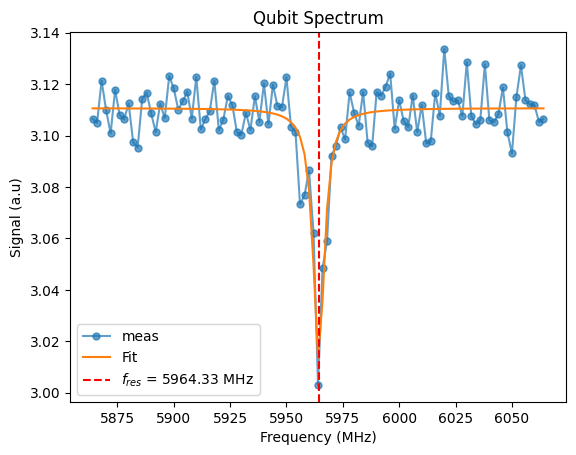

In [357]:
pyavg = 50
qspec=PulseProbeSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)

f_q = spectrum_analyze(freqs, np.abs(iq_list[0][0].dot([1,1j])))
config['f_ge'] = round(f_q, 3)
config['qmixer_freq']= round(f_q,3)

In [358]:
data_path = data_path
exp_name = f"q{qubit_idx+1} qubit spec"
try:
        run_cfg.pop('f_ge')
except:
        pass
dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e3},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'f_q = {f_q} MHz\
                 \nYoko = {Yoko_current} mA\
                 \n{run_cfg["res_gain"]}, qb_gain={run_cfg["qubit_gain"]}\
                 \n\n{dict_val}'),
        tag='TwoTone')

# Qubit Flux Spec

  0%|          | 0/21 [00:00<?, ?it/s]

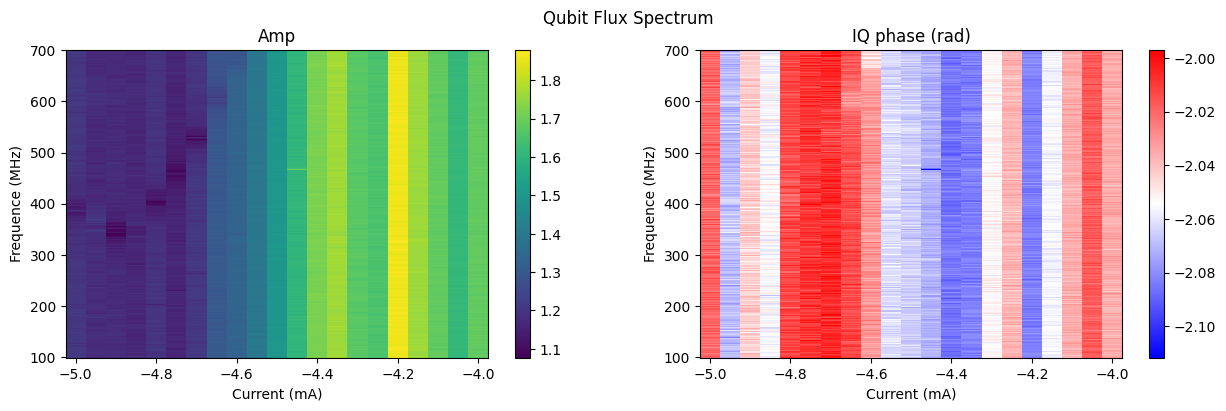

In [ ]:
Start_flux = -5 # [mA]
Stop_flux = -4 # [mA]
Steps = 21

cemter = 400

START_FREQ = cemter - 300# [MHz]
STOP_FREQ = cemter + 300  # [MHz]
STEPS = 300
config.update({'qmixer_freq':cemter,'qubit_gain': 0.1, 'res_gain':0.1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
     }

run_cfg = {**config, **expt_cfg}
pyavg = 100


### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps)*1e-3

z=[]
for i in tqdm(flux):
    yoko_global.setValue(sQuant='Current', value=i, rate=10e-6)
    qspec=PulseProbeSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
    iq_list = qspec.acquire(soc, soft_avgs=pyavg, progress=False)
    qb_spec = iq_list[0][0].dot([1,1j])
    z.append(qb_spec)

freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)


avg_abs, avg_angle = np.abs(z), np.angle(z)

fig, axes = plt.subplots(1, 2, figsize=(15,4))
fig.suptitle('Qubit Flux Spectrum')
for i, d in enumerate([avg_abs, avg_angle]):
    if i==0:
        pcm = axes[i].pcolormesh(flux*1e3, freqs, d.T, shading="Auto")
    else:
        pcm = axes[i].pcolormesh(flux*1e3, freqs, np.unwrap(d).T, shading="Auto", cmap="bwr")
    axes[i].set_ylabel("Frequence (MHz)")
    axes[i].set_xlabel("Current (mA)")
    axes[i].set_title("Amp" if i ==0  else "IQ phase (rad)")
    plt.colorbar(pcm, ax=axes[i])

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} qubit flux spec"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  
        y_info={'name': 'Flux', 'unit': "A",
                'values': flux},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array(z)},
                
        comment=f'',
        tag='TwoTone'
)

# Qubit flux spec zcu

In [19]:
class PulseProbeSpectroscopyProgramFF(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="qubit_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       style="flat_top", 
                       envelope="qubit_ramp",
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )
        ## test ff pulse ##
        ff_ch = cfg['ff_ch']
        self.declare_gen(ch=ff_ch, nqz=1, mixer_freq=0)
        self.add_pulse(ch=ff_ch, name="ff_pulse",
                       style="const", 
                       length=cfg['ff_len'], 
                       freq=0, 
                       phase= 0,
                       gain=cfg['ff_gain'],
                      )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["ff_ch"], name="ff_pulse", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Length Rabi

In [25]:
class LengthRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        # self.add_loop("lenloop", cfg["steps"])
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse

        self.delay_auto(t=0.0, tag='waiting')
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

  0%|          | 0/50 [00:00<?, ?it/s]

(0.171, 0.081)

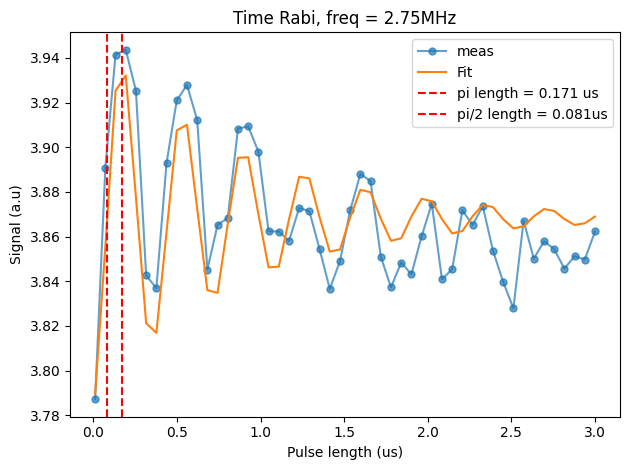

In [26]:
START_LEN = 0.01 # [DAC units]
STOP_LEN = 3 # [DAC units]
STEPS = 50

config.update({'relax_delay':50, 'qb_pulse_style':'flat_top', 'sigma':0.1, 'flat_top_len':0.1, 'nqz':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    'qubit_gain': 0.8
     }
run_cfg = {**config, **expt_cfg}

length = np.linspace(START_LEN, STOP_LEN, STEPS)
length_rabi=[]
for i in tqdm(length):
    run_cfg['flat_top_len'] = i
    prog = LengthRabiProgram(soccfg,reps=100,final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = prog.acquire(soc, rounds=50, progress=False)
    # t = prog.get_pulse_param('qubit_pulse', "length", as_array=True)
    length_rabi.append(iq_list[0][0].dot([1,1j]))
length_rabi = np.array(length_rabi)
lengthrabi_analyze(length, length_rabi)

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} length rabi"


file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': length*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values': np.array(amp)},
        comment=f'relax = {run_cfg["relax_delay"]} us, \n{run_cfg}',
        tag='Rabi')

# Power Rabi

In [339]:
class AmplitudeRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['rabi_protocal'] == 'pi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        elif self.cfg['rabi_protocal'] == 'pipi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
            self.delay_auto(0.0)
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [365]:
START_GAIN = 0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 100


config.update({'relax_delay':50, 'qb_pulse_style':'arb', 'sigma':0.03, 'flat_top_len':2, 'nqz':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
    'ro_len':1
     }
run_cfg = {**config, **expt_cfg}

In [366]:
pyavg = 2500
run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], config['pi2_gain'] = amprabi_analyze(gains, (iq_list[0][0].dot([1,1j])), protocal=None)

  0%|          | 0/2500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} power rabi"


file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'relax={run_cfg["relax_delay"]}, at {Yoko_current}mA\
                \n\n{run_cfg}',
        tag='Rabi')

## Fine Tune Power Rabi

In [92]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 100


config.update({'relax_delay':50, 'qb_pulse_style':'arb', 'sigma':0.1, 'flat_top_len':0.5})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain":QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
     }
run_cfg = {**config, **expt_cfg}

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

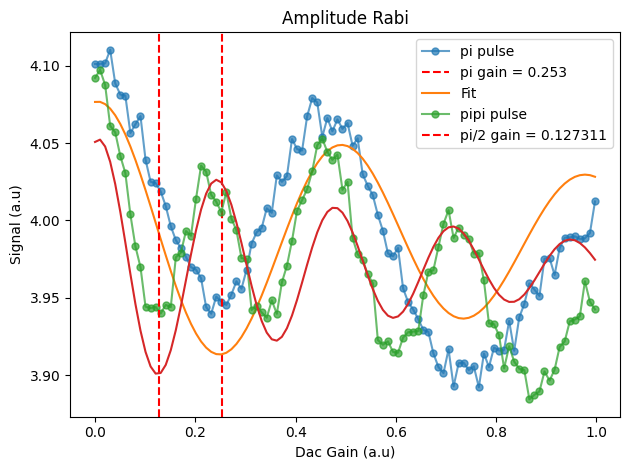

In [94]:
pyavg = 30
run_cfg = {**config, **expt_cfg}

run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, rounds=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=run_cfg['rabi_protocal'])

run_cfg['rabi_protocal']='pipi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, rounds=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi2 = iq_list[0][0].dot([1,1j])
config['pi2_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=run_cfg['rabi_protocal'])

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} power rabi fine tune"

try:
    run_cfg.pop('qubit_gain')
except:
    pass
dict_val = yml_comment(run_cfg)
file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        y_info={'name': '# pi pulse ', 'unit': "#",
                'values': [1,2]},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array([power_rabi, power_rabi2])},
        comment=f'relax={run_cfg["relax_delay"]}, at {Yoko_current}mA\
                \n\n{dict_val}',
        tag='Rabi')

# Fast flux rabi

In [178]:
class AmplitudeRabiProgramFF(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        ff_ch = cfg['ff_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("ffgainloop", cfg["stepsff"])
        self.add_loop("gainloop", cfg["steps"])

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        ff_ch = cfg['ff_ch']
        self.declare_gen(ch=ff_ch, nqz=1, mixer_freq=0)
        self.add_pulse(ch=ff_ch, name="ff_pulse", 
                       style="const",
                       length=cfg['ff_len'], 
                       freq=0, 
                       phase=0,
                       gain=cfg['ff_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["ff_ch"], name="ff_pulse", t=0)
        
        if self.cfg['rabi_protocal'] == 'pi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        elif self.cfg['rabi_protocal'] == 'pipi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [179]:
START_GAIN = 0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 100


config.update({'relax_delay':30, 'qb_pulse_style':'arb', 'sigma':0.01, 'flat_top_len':2, 'nqz':2,'qubit_ch':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
    ## Fast Flux Params. ##
    'ff_ch': 14, # Fast Flux channel
    'ff_len': 0.02, # [s]
    'ff_gain': QickSweep1D('ffgainloop', -1, 1), # [DAC units]
    'stepsff': 11, # Number of sweep points for fast flux
     }
run_cfg = {**config, **expt_cfg}

In [180]:
pyavg = 20
run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgramFF(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
flux_gain = amp_rabi.get_pulse_param('ff_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])


  0%|          | 0/20 [00:00<?, ?it/s]

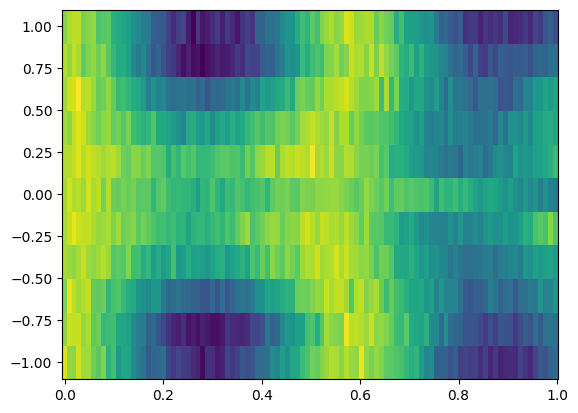

In [185]:
plt.pcolor(gains, flux_gain, np.abs(power_rabi), shading="Auto")

In [186]:
class AmplitudeRabiProgramFF(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        ff_ch = cfg['ff_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        ff_ch = cfg['ff_ch']
        self.declare_gen(ch=ff_ch, nqz=1, mixer_freq=0)
        self.add_pulse(ch=ff_ch, name="ff_pulse", 
                       style="const",
                       length=cfg['ff_len'], 
                       freq=0, 
                       phase=0,
                       gain=cfg['ff_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["ff_ch"], name="ff_pulse", t=0)
        
        if self.cfg['rabi_protocal'] == 'pi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        elif self.cfg['rabi_protocal'] == 'pipi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
START_GAIN = 0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 100


config.update({'relax_delay':30, 'qb_pulse_style':'arb', 'sigma':0.01, 'flat_top_len':2, 'nqz':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
    ## Fast Flux Params. ##
    'ff_ch': 14, # Fast Flux channel
    'ff_len': 0.02, # [s]
    'ff_gain':-1, # [DAC units]
    'stepsff': 11, # Number of sweep points for fast flux
     }
run_cfg = {**config, **expt_cfg}
pyavg = 20
run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgramFF(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])


  0%|          | 0/20 [00:00<?, ?it/s]

(0.293374, 0.145164)

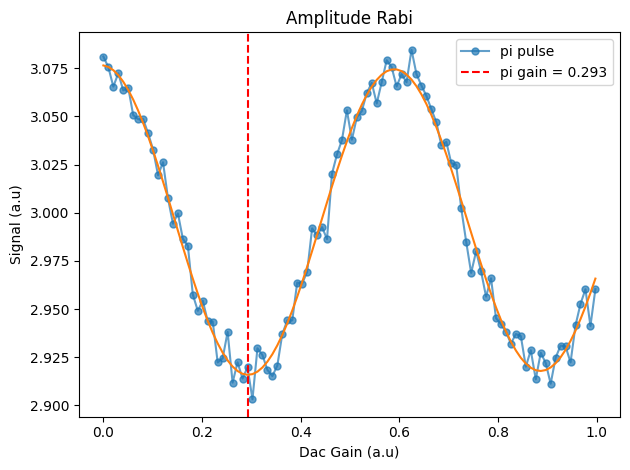

In [187]:
amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=run_cfg['rabi_protocal'])

# chi exp

In [40]:
class ChiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("freqloop", cfg["steps"])

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [106]:
center = r[qubit_idx]
START_FREQ = center - 5 # [MHz]
STOP_FREQ =  center + 5 # [MHz]
STEPS = 101

exp_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'relax_delay': 50, # [us]
    'res_gain': 0.4
}

run_cfg = {**config, **exp_cfg}

  0%|          | 0/30 [00:00<?, ?it/s]

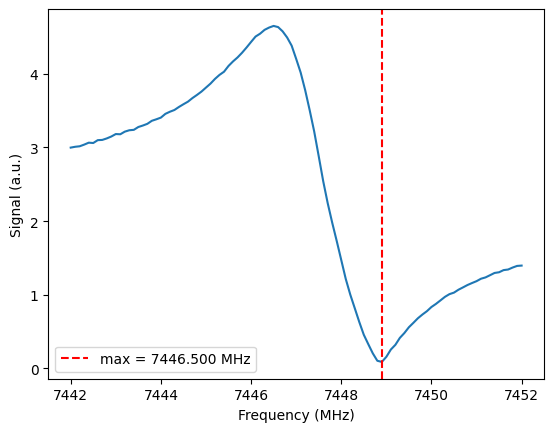

In [107]:
pyavg = 30

prog = ChiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
chi = (iq_list[0][0].dot([1,1j]))
plt.plot(freqs, np.abs(chi))
plt.axvline(freqs[np.argmin(np.abs(chi))], color='r', 
            linestyle='--', label=f'max = {freqs[np.argmax(np.abs(chi))]:.3f} MHz')
plt.xlabel("Frequency (MHz)")
plt.ylabel("Signal (a.u.)")
plt.legend()
config['f_res'] = freqs[np.argmin((np.abs(chi)))]


## photon

In [194]:
class PhotonProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("waitloop", cfg["steps_t"])
        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_pulse(ch=res_ch, name="pump", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=1, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=0.2,
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=1,
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=1,
                           length = 0.25
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="pump", t=0)
        self.delay_auto(cfg['wait_time'], tag='wait') 
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [195]:
cemter = 5900
SPAN = 10
START_FREQ = 5900 # [MHz]
STOP_FREQ = 6000 # [MHz]
STEPS = 61


expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'steps_t':21,
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'wait_time': QickSweep1D('waitloop', 0, 0.4), # [us]
     }

run_cfg = {**config, **expt_cfg}

In [196]:
run_cfg['qb_pulse_style'] = 'flat_top'
run_cfg['sigma'] = 0.005

In [197]:
pyavg = 50
photon=PhotonProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = photon.acquire(soc, rounds=pyavg, progress=True)
freqs = photon.get_pulse_param('qubit_pulse', "freq", as_array=True)
delay_times = photon.get_time_param('wait', "t", as_array=True)
photon_data = iq_list[0][0].dot([1,1j])


  0%|          | 0/50 [00:00<?, ?it/s]

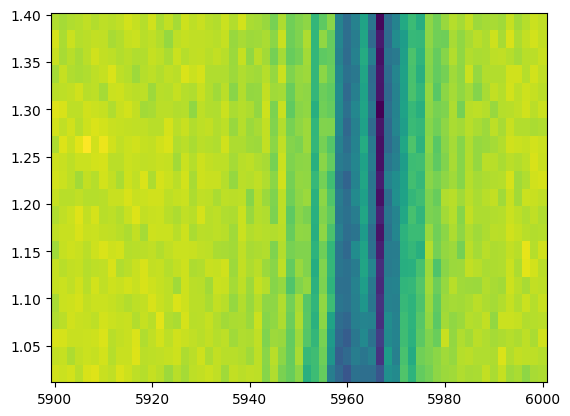

In [198]:
plt.pcolormesh(freqs, delay_times, np.abs(photon_data))

In [263]:
data_path = data_path
exp_name = f"R{qubit_idx+1} res photon"

try:
        run_cfg.pop['f_res']
        run_cfg.pop['wait_time']
except:
        pass

file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  
        y_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  photon_data},
        comment=f'',
        tag='OneTone'
)

2025-06-30 16:44:17,954 - SR_Network:BlockingClient - Error: Socket operation timed out


# Ramsey Fringe Experiment

In [141]:
class RamseyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_loop("waitloop", cfg["steps"])
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )

            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp", 
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp",
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)  
        
        self.delay_auto(cfg['wait_time'], tag='wait') 
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  

        self.delay_auto(0.05) 
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) 
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [160]:
START_TIME = 0. # [us]
STOP_TIME = 5 # [us]
STEPS = 100

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'ramsey_freq':-2,
    }

run_cfg = {**config, **expt_cfg}


  0%|          | 0/50 [00:00<?, ?it/s]

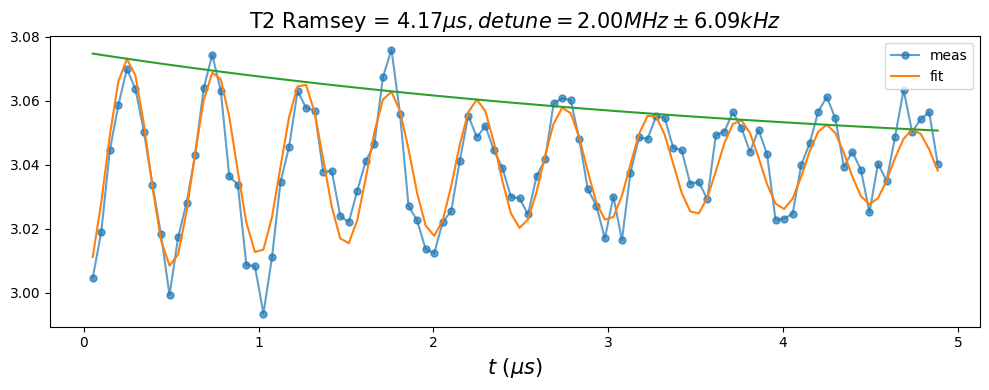

In [161]:
pyavg = 50

ramsey=RamseyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = ramsey.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times = ramsey.get_time_param('wait', "t", as_array=True)
ramsey = iq_list[0][0].dot([1,1j])

t2r = T2fring_analyze(delay_times, (ramsey), prefix='Ramsey')

In [159]:
activate_correct=True
if activate_correct:
    if abs(t2r[1]-run_cfg['ramsey_freq'])>0.0001:
        config['f_ge'] = config['f_ge']-round((t2r[1]-run_cfg['ramsey_freq']),5)
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),5)}')
        print('Correct')
    else:
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),5)}')

over detune 5.89276
Correct


In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T2 Ramsey "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'Detune = {t2r[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2R = {t2r[3]:.2f}us\
                \nYokogawa = {Yoko_current}mA\
                \n\n{dict_val}'),
        tag='T2')

# Spin Echo Experiment

In [53]:
class SpinEchoProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'],
                       freq=cfg['f_res'],
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase']+ cfg['wait_time']*360*cfg['ramsey_freq'], 
                        gain=cfg['pi2_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'], 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi2_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'], 
                           gain=cfg['pi2_gain'],
                          )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse1", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait1') # wait_time after last pulse (wait / 2)
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse_pi", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait2') # wait_time after last pulse (wait / 2)

        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  #play pulse

        self.delay_auto(0.01) # wait_time after last pulse
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [309]:
START_TIME = 0.0 # [us]
STOP_TIME = 10 # [us]
STEPS = 100

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'ramsey_freq':0.8,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/50 [00:00<?, ?it/s]

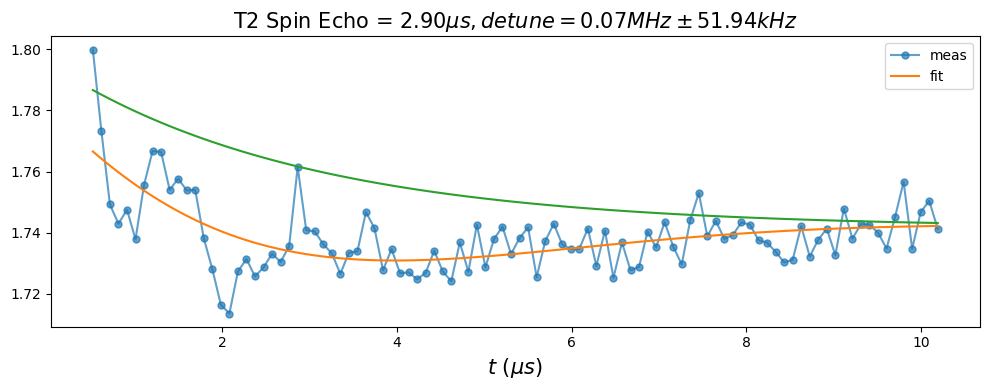

In [310]:
pyavg = 50

spinecho=SpinEchoProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = spinecho.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
spinecho = iq_list[0][0].dot([1,1j])

t2e = T2fring_analyze(delay_times1+delay_times2, spinecho,  prefix='Spin Echo')

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T2 SpinEcho "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': (delay_times1+delay_times2)*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'detune = {t2e[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2E = {t2e[3]:.2f}us\
                \nYokogawa = {-4.2}mA\
                \n\n{dict_val}'),
        tag='T2')

# T1

In [344]:
class T1Program(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])


        self.add_gauss(ch=res_ch, name="res", sigma=0.01, length=0.01*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top",
                       envelope='res',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", ro_ch=ro_ch, 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", ro_ch=ro_ch, 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],

                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(cfg['wait_time']+0.05, tag='wait') # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [350]:
START_TIME = 0.0 # [us]
STOP_TIME = 50.0 # [us]
STEPS = 50

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'relax_delay': 50,
    }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\csutscrip\data_fitting\fitting.py:107: RuntimeWarning: overflow encountered in exp
  return y0 + yscale * np.exp(-(x - x0) / decay)


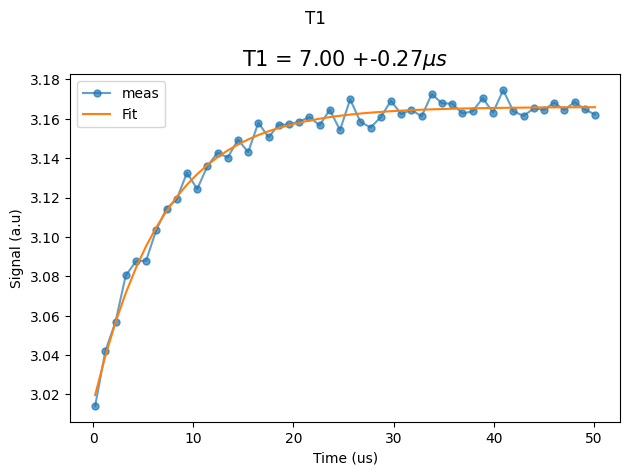

In [351]:
pyavg = 50
T1=T1Program(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
# iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=True, threshold=run_cfg['thresholds'])
iq_list = T1.acquire(soc, rounds=pyavg, progress=True)
delay_times = T1.get_time_param('wait', "t", as_array=True)

t1 = T1_analyze(delay_times, (iq_list[0][0].dot([1,1j])))

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T1"

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'T1 = {t1[3]:.2f}us,\
                \nYokogawa = {Yoko_current}mA\
                \n\n {dict_val}',
        tag='T1')

# Single shot

In [63]:
# Separate g and e per each experiment defined.

class SingleShotProgram_g(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots

        self.add_gauss(ch=res_ch, name="res", sigma=0.01, length=0.01*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top",
                       envelope='res',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # no qubit pulse
        self.delay_auto(0.01, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


class SingleShotProgram_e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots
        self.add_gauss(ch=res_ch, name="res", sigma=0.008, length=0.008*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope='res',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        if cfg['qb_pulse_style']=='arb':
            self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase'],
                        gain= cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="flat_top", 
                        envelope="ramp", 
                        length=cfg['flat_top_len'], 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(0.02, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [136]:
SHOTS = 10000
# run_cfg = {**config, **expt_cfg}
run_cfg['steps'] = SHOTS
ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=True)

ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [135]:
run_cfg

{'res_ch': 0,
 'ro_ch': 0,
 'qubit_ch': 5,
 'f_res': 7446.618,
 'res_len': 10,
 'res_phase': 0,
 'res_gain': 0.55,
 'res_sigma': 0.004,
 'trig_time': 0.49,
 'ro_len': 4.3,
 'relax_delay': 50,
 'thresholds': None,
 'qb_pulse_style': 'arb',
 'f_ge': 5963.715,
 'nqz': 1,
 'qubit_gain': <qick.asm_v2.QickParam at 0x17f0ab355b0>,
 'probe_len': 5,
 'flat_top_len': 2,
 'pi_gain': 0.600277,
 'pi2_gain': 0.323069,
 'qubit_phase': 0,
 'sigma': 0.2,
 'ramsey_freq': 3,
 'qmixer_freq': 5963.715,
 'steps': 10000,
 'rabi_protocal': 'pi'}

g unrotated averages:
I -0.8374813777441331 +/- 0.5511302677881915 	 Q -6.201773050719152 +/- 0.5265654564114859 	 Amp 6.2825265553927805 +/- 0.5236791607818655
Rotated (theta=-2.801980089777989):
I -1.276298239257914 +/- 0.5538486262768869 	 Q 6.126534651429117 +/- 0.5237055003810113 	 Amp 6.258063920310701 +/- 0.5236791607818655
e unrotated averages:
I -1.1199943224829672 +/- 0.6672555247935864 	 Q -6.101960938682816 +/- 0.5478626626341425 	 Amp 6.241214452674336 +/- 0.5300378928058671
Rotated (theta=-2.801980089777989):
I -0.9766717690418105 +/- 0.6820280750567449 	 Q 6.126534651429117 +/- 0.5293591760898527 	 Amp 6.203895113523838 +/- 0.5300378928058671


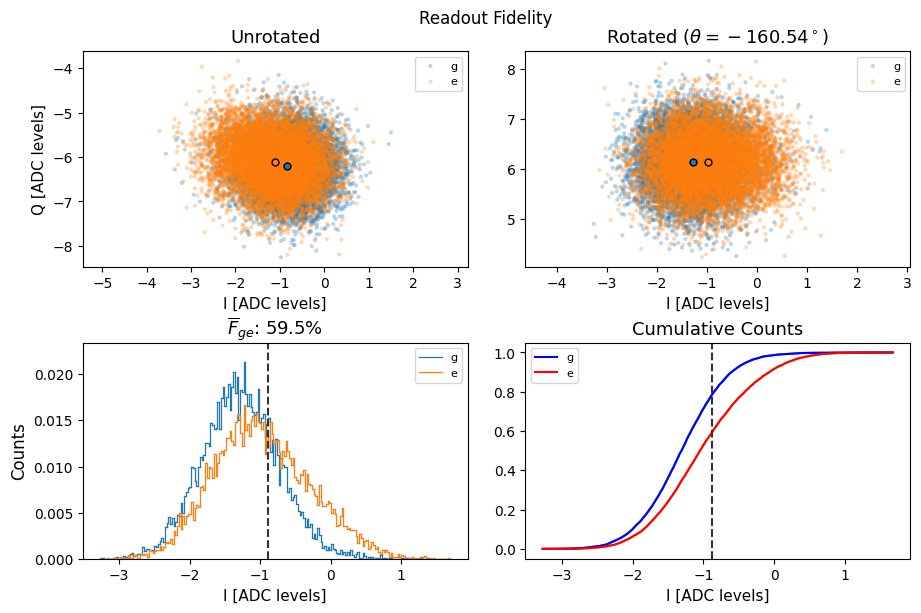

fidelity:[0.5952] 
thressholds:[-0.8855117161034829] 
theta:-160.54163342396626


In [137]:
I_g = iq_list_g[0][0].T[0]
Q_g = iq_list_g[0][0].T[1]
I_e = iq_list_e[0][0].T[0]
Q_e = iq_list_e[0][0].T[1]


data={
    "Ig":I_g,
    "Qg": Q_g,
    "Ie": I_e,
    "Qe": Q_e
}
f = histplot(data, fid_avg=True, fit=False, gauss_overlap=False)

## Readout Optimization

## Gain VS Frequency

In [72]:
freq_steps = 20
freq_step_size = 0.05 # [MHz]
freq_start = (config['f_res']) - ((freq_steps/2)*freq_step_size)
gain_steps = 18
gain_step_size = 0.05 # [DAC units]
gain_start = 0.05
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for gains in tqdm(range(gain_steps), desc='Gain loop', leave=False):
        run_cfg.update({
            ## Sweep Params: ##
            'steps': SHOTS, # Number of shot points (outer loop)
            'f_res': freq_start + freq_step_size*freqs, # [MHz]
            'res_gain': gain_start + gain_step_size*gains, # [DAC units]
        
            })

        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

...

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_19432\3339831831.py:38: UserWarning: The following kwargs were not used by contour: 'interpolation'
  figB = plt.contour(gains_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')


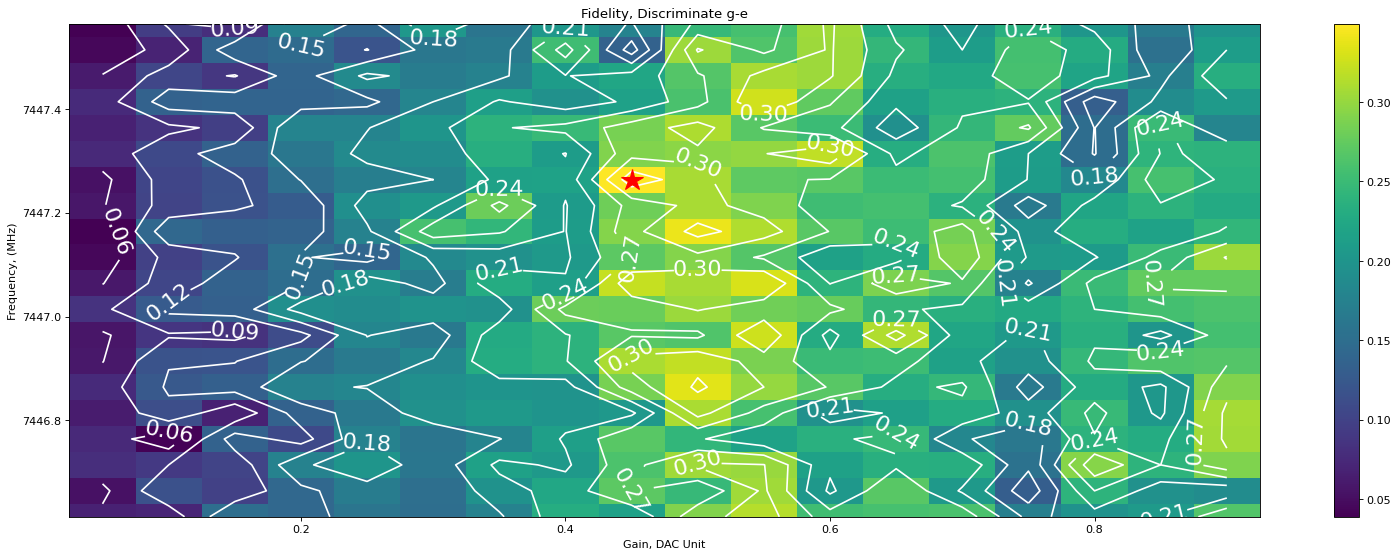

7447.263999999999 0.45


In [73]:
fid_Array =np.zeros([freq_steps,gain_steps])
for index_freq in range(freq_steps):
    for index_amp in range(gain_steps):
        I_g = I_g_array[index_freq][0][index_amp][0]
        Q_g = Q_g_array[index_freq][0][index_amp][0]
        I_e = I_e_array[index_freq][0][index_amp][0]
        Q_e = Q_e_array[index_freq][0][index_amp][0]


        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q) ** 2


        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom

        th_list = np.linspace(min(gstate), max(estate), 1000)
        gstate = gstate.reshape(1, -1)
        estate = estate.reshape(1, -1)
        th_list = th_list.reshape(-1, 1)

        g_cdf = np.sum(gstate < th_list, axis=1) / gstate.shape[1]
        e_cdf = np.sum(estate > th_list, axis=1) / estate.shape[1]
        fidelity = (g_cdf + e_cdf) / 2
        fid_Array[index_freq, index_amp] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
gains_list = np.zeros(gain_steps)
for gain in range(gain_steps):
    gains_list[gain] = gain_start + gain_step_size*gain
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(gains_list,freqs_list,fid_Array)
figB = plt.contour(gains_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"Gain, DAC Unit")
plt.ylabel(r"Frequency, (MHz)")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_gain_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_gain = gains_list[max_gain_idx]
plt.plot(max_gain, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.title(r"Fidelity, Discriminate g-e")
plt.colorbar(figA)
plt.show()
print(max_freq, max_gain)
run_cfg['f_res'] = round(max_freq,3)
run_cfg['res_gain'] = round(max_gain,3)
#plt.savefig("FidwithoutJPA.png",dpi=300,bbox_inches='tight')

### Length VS Frequency

In [68]:
freq_steps = 20
freq_step_size = 0.2 # [MHz]
freq_start = (config['f_res']) - ((freq_steps/2)*freq_step_size)
length_steps = 20
length_step_size = 0.2 # [us units]
length_start = 0.5
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for lengths in tqdm(range(length_steps), desc='ro len loop', leave=False):
        run_cfg.update({'steps': SHOTS,
                        'f_res': freq_start + freq_step_size*freqs,
                        'ro_len': length_start + length_step_size*lengths,
                        })


        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

...

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_19432\1858233137.py:38: UserWarning: The following kwargs were not used by contour: 'interpolation'
  figB = plt.contour(lengths_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')


7446.714 2.7


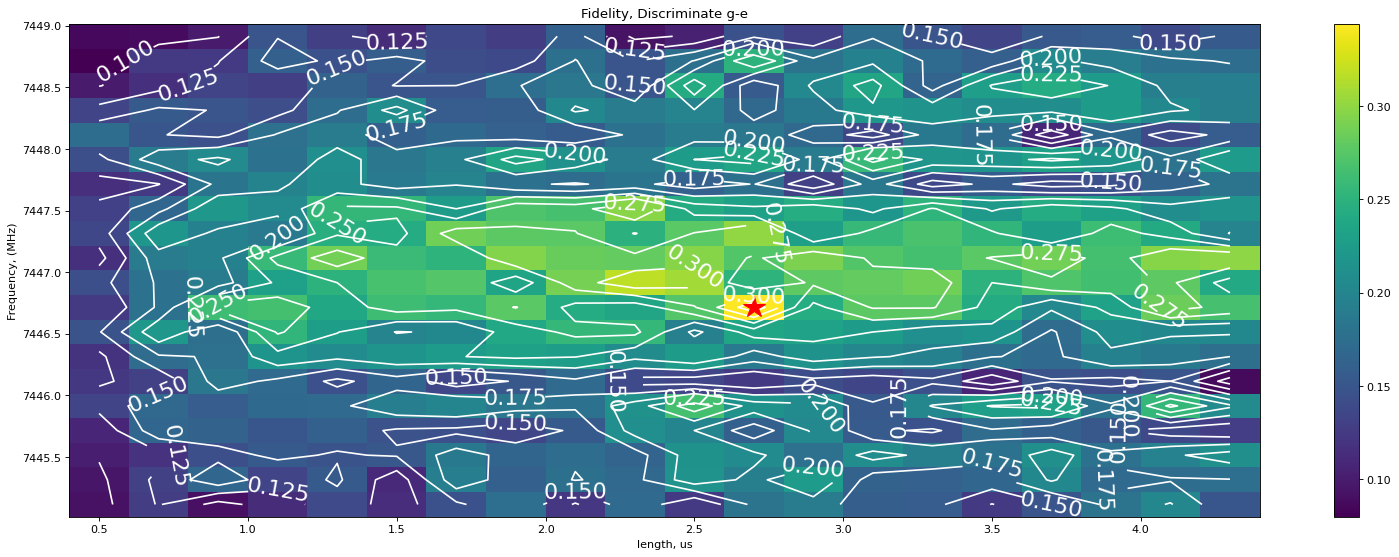

In [69]:
fid_Array = np.zeros((freq_steps, length_steps))

for index_freq in range(freq_steps):
    for index_length in range(length_steps):
        I_g = I_g_array[index_freq][0][index_length][0]
        Q_g = Q_g_array[index_freq][0][index_length][0]
        I_e = I_e_array[index_freq][0][index_length][0]
        Q_e = Q_e_array[index_freq][0][index_length][0]

        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q)**2

        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom


        th_list = np.linspace(np.min(gstate), np.max(estate), 1000).reshape(-1, 1)
        g_proj = np.array(gstate).reshape(1, -1)
        e_proj = np.array(estate).reshape(1, -1)

        g_cdf = np.sum(g_proj < th_list, axis=1) / g_proj.shape[1]
        e_cdf = np.sum(e_proj > th_list, axis=1) / e_proj.shape[1]
        fidelity = (g_cdf + e_cdf) / 2

        fid_Array[index_freq, index_length] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
lengths_list = np.zeros(length_steps)
for length in range(length_steps):
    lengths_list[length] = length_start + length_step_size*length
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(lengths_list,freqs_list,fid_Array)
figB = plt.contour(lengths_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"length, us")
plt.ylabel(r"Frequency, (MHz)")
plt.title(r"Fidelity, Discriminate g-e")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_length_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_length = lengths_list[max_length_idx]
plt.plot(max_length, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.colorbar(figA)

print(max_freq, max_length)
run_cfg['f_res'] = round(max_freq, 3)
run_cfg['ro_len'] = round(max_length, 2)

### Gain vs Length

In [39]:
gain_steps = 14
gain_step_size = 0.05 # [DAC units]
gain_start = 0.05

length_steps = 10
length_step_size = 0.2 # [us units]
length_start = 0.5
SHOTS = 100

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(gain_steps), desc='Gain loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for lengths in tqdm(range(length_steps), desc='ro len loop', leave=False):
        run_cfg.update({'steps': SHOTS,
                        'f_res': 5799,
                        'ro_len': length_start + length_step_size*lengths,
                        'res_gain': gain_start + gain_step_size*gains, # [DAC units]
                        })


        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/10 [00:00<?, ?it/s]

TypeError: only size-1 arrays can be converted to Python scalars

In [ ]:
# fid_Array = np.zeros((gain_steps, length_steps))

# for index_gain in range(gain_steps):
#     for index_length in range(length_steps):
#         I_g = I_g_array[index_gain][0][index_length][0]
#         Q_g = Q_g_array[index_gain][0][index_length][0]
#         I_e = I_e_array[index_gain][0][index_length][0]
#         Q_e = Q_e_array[index_gain][0][index_length][0]

#         vec_I = np.mean(I_e) - np.mean(I_g)
#         vec_Q = np.mean(Q_e) - np.mean(Q_g)
#         denom = np.abs(vec_I + 1j * vec_Q)**2

#         gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
#         estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom


#         th_list = np.linspace(np.min(gstate), np.max(estate), 1000).reshape(-1, 1)
#         g_proj = np.array(gstate).reshape(1, -1)
#         e_proj = np.array(estate).reshape(1, -1)

#         g_cdf = np.sum(g_proj < th_list, axis=1) / g_proj.shape[1]
#         e_cdf = np.sum(e_proj > th_list, axis=1) / e_proj.shape[1]
#         fidelity = (g_cdf + e_cdf) / 2

#         fid_Array[index_gain, index_length] = 2 * np.max(fidelity) - 1


# gain_list = np.zeros(gain_steps)
# lengths_list = np.zeros(length_steps)
# for length in range(length_steps):
#     lengths_list[length] = length_start + length_step_size*length
# for gain in range(gain_steps):
#     gain_list[gain] = gain_start + gain_step_size*gain

# plt.figure(figsize=(24, 8), dpi=80)
# figA = plt.pcolormesh(lengths_list,gain_list,fid_Array)
# figB = plt.contour(lengths_list,gain_list,fid_Array, 10 ,colors='w',interpolation='none')
# plt.clabel(figB, figB.levels, inline=True, fontsize=20)
# plt.xlabel(r"length, us")
# plt.ylabel(r"Gain (Dac unit)")
# plt.title(r"Fidelity, Discriminate g-e")
# max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
# max_gain_idx, max_length_idx = max_idx
# max_gain = gain_list[max_gain_idx]
# max_length = lengths_list[max_length_idx]
# plt.plot(max_length, max_gain, marker='*', color='red', markersize=20, label='Max Fidelity')
# plt.colorbar(figA)
# plt.show()
# print(max_gain, max_length)

IndexError: list index out of range

## all

In [132]:
freq_steps = 20
freq_step_size = 0.05 # [MHz]
freq_start = (config['f_res']) - ((freq_steps/2)*freq_step_size)

gain_steps = 18
gain_step_size = 0.05 # [DAC units]
gain_start = 0.05


length_steps = 20
length_step_size = 0.2 # [us units]
length_start = 0.5

SHOTS = 1000


I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for length_idx in tqdm(range(length_steps), desc='Length loop'):
    I_g_length = []
    Q_g_length = []
    I_e_length = []
    Q_e_length = []
    for gain_idx in tqdm(range(gain_steps), desc='Gain loop', leave=False):
        I_g_gain = []
        Q_g_gain = []
        I_e_gain = []
        Q_e_gain = []
        for freq_idx in tqdm(range(freq_steps), desc='Freq loop', leave=False):
            run_cfg.update({
                'steps': SHOTS,
                'f_res': freq_start + freq_step_size * freq_idx,
                'res_gain': gain_start + gain_step_size * gain_idx,
                'ro_len': length_start + length_step_size * length_idx
            })

            ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
            iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

            ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
            iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

            I_g = iq_list_g[0][0].T[0]
            Q_g = iq_list_g[0][0].T[1]
            I_e = iq_list_e[0][0].T[0]
            Q_e = iq_list_e[0][0].T[1]

            I_g_gain.append(I_g)
            Q_g_gain.append(Q_g)
            I_e_gain.append(I_e)
            Q_e_gain.append(Q_e)

        I_g_length.append(I_g_gain)
        Q_g_length.append(Q_g_gain)
        I_e_length.append(I_e_gain)
        Q_e_length.append(Q_e_gain)

    I_g_array.append(I_g_length)
    Q_g_array.append(Q_g_length)
    I_e_array.append(I_e_length)
    Q_e_array.append(Q_e_length)

I_g_array = np.array(I_g_array)
Q_g_array = np.array(Q_g_array)
I_e_array = np.array(I_e_array)
Q_e_array = np.array(Q_e_array)


Length loop:   0%|          | 0/20 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

...

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

In [133]:
fid_Array = np.zeros((length_steps, gain_steps, freq_steps))

for length_idx in tqdm(range(length_steps), desc='Analyze max fidelity'):
    for gain_idx in range(gain_steps):
        for freq_idx in range(freq_steps):
            I_g = I_g_array[length_idx][gain_idx][freq_idx]
            Q_g = Q_g_array[length_idx][gain_idx][freq_idx]
            I_e = I_e_array[length_idx][gain_idx][freq_idx]
            Q_e = Q_e_array[length_idx][gain_idx][freq_idx]

            vec_I = np.mean(I_e) - np.mean(I_g)
            vec_Q = np.mean(Q_e) - np.mean(Q_g)
            denom = np.abs(vec_I + 1j * vec_Q)**2

            gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
            estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom

            th_list = np.linspace(np.min(gstate), np.max(estate), 1000).reshape(-1, 1)
            g_proj = np.array(gstate).reshape(1, -1)
            e_proj = np.array(estate).reshape(1, -1)

            g_cdf = np.sum(g_proj < th_list, axis=1) / g_proj.shape[1]
            e_cdf = np.sum(e_proj > th_list, axis=1) / e_proj.shape[1]
            fidelity = (g_cdf + e_cdf) / 2

            fid_Array[length_idx, gain_idx, freq_idx] = 2 * np.max(fidelity) - 1
            
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_length_idx, max_gain_idx, max_freq_idx = max_idx

max_length = length_start + length_step_size * max_length_idx
max_gain = gain_start + gain_step_size * max_gain_idx
max_freq = freq_start + freq_step_size * max_freq_idx

print(f"Max fidelity: {np.max(fid_Array):.4f}")
print(f"At length={max_length:.3f} us, gain={max_gain:.3f} DAC, freq={max_freq:.3f} MHz")
run_cfg['ro_len'] = round(max_length, 2)
run_cfg['res_gain'] = round(max_gain, 3)
run_cfg['f_res'] = round(max_freq, 3)

Analyze max fidelity:   0%|          | 0/20 [00:00<?, ?it/s]

Max fidelity: 0.3810
At length=4.300 us, gain=0.550 DAC, freq=7446.618 MHz


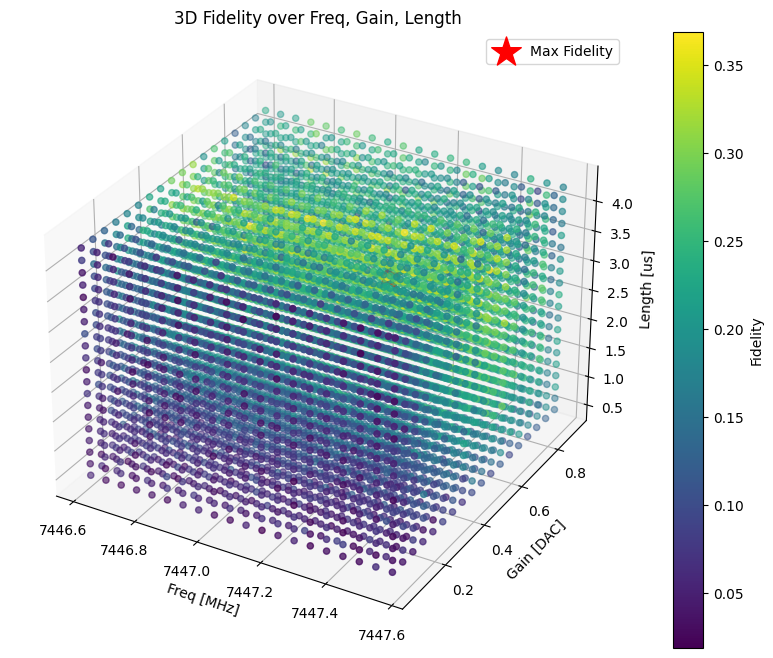

In [87]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

lengths = np.linspace(length_start, length_start + length_step_size * (length_steps - 1), length_steps)
gains = np.linspace(gain_start, gain_start + gain_step_size * (gain_steps - 1), gain_steps)
freqs = np.linspace(freq_start, freq_start + freq_step_size * (freq_steps - 1), freq_steps)

L, G, F = np.meshgrid(lengths, gains, freqs, indexing='ij')  # shape = (length, gain, freq)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 展平為 1D
sc = ax.scatter(F.flatten(), G.flatten(), L.flatten(), c=fid_Array.flatten(), cmap='viridis')
ax.set_xlabel("Freq [MHz]")
ax.set_ylabel("Gain [DAC]")
ax.set_zlabel("Length [us]")
ax.set_title("3D Fidelity over Freq, Gain, Length")

# 標註最大值
ax.scatter(
    freqs[max_freq_idx],
    gains[max_gain_idx],
    lengths[max_length_idx],
    color='red', marker='*', s=500, label='Max Fidelity'
)

fig.colorbar(sc, ax=ax, label='Fidelity')
ax.legend()
plt.show()


# Track

In [ ]:
import time
from datetime import datetime
import os
import pandas as pd
import numpy as np

pyavg = 50
filename = "monitor_log.csv"
i=0


import csv
if not os.path.exists(filename):
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp", "T2r", "T2e", "T1"])  # 正確寫入標題
try:
    while True:
        now = datetime.now()
        print(f"Measurement at {now.strftime('%Y-%m-%d %H:%M:%S')}")
        ## T2R ##
        START_TIME = 0.01 # [us]
        STOP_TIME = 2 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            'ramsey_freq':3
            }
        run_cfg = {**config, **expt_cfg}
        ramsey=RamseyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = ramsey.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times = ramsey.get_time_param('wait', "t", as_array=True)
        ramsey = iq_list[0][0].dot([1,1j])
        t2r = T2fring_analyze(delay_times, ramsey)

        ## T2E ##
        START_TIME = 0.01 # [us]
        STOP_TIME = 2 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'ramsey_freq':3,
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            }
        run_cfg = {**config, **expt_cfg}
        spinecho=SpinEchoProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = spinecho.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
        delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
        spinecho = iq_list[0][0].dot([1,1j])
        t2e = T2fring_analyze(delay_times1+delay_times2, np.abs(spinecho))

        ## T1 ##
        START_TIME = 0.05 # [us]
        STOP_TIME = 60.0 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            }
        run_cfg = {**config, **expt_cfg}
        T1=T1Program(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times = T1.get_time_param('wait', "t", as_array=True)
        t1 = T1_analyze(delay_times, np.abs(iq_list[0][0].dot([1,1j])))

        t2r_list = [t2r[3], t2r[1]-3]
        t2e_list = [t2e[3], t2e[1]-3]
        t1_value = t1[3]
        with open(filename, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([now.isoformat(), t2r_list, t2e_list, t1_value])
except KeyboardInterrupt:

    print("\n手動中斷量測，資料已保留。")


# Dispersive shift

In [76]:
class Dispersive_e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=2, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=2)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=100, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(0.015, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

class Dispersive_g(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=2, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=2)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=100, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)


        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [77]:
center = r[qubit_idx]
START_FREQ = center - 5 # [MHz]
STOP_FREQ =  center + 5 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.4
}
run_cfg = {**config, **exp_cfg}

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

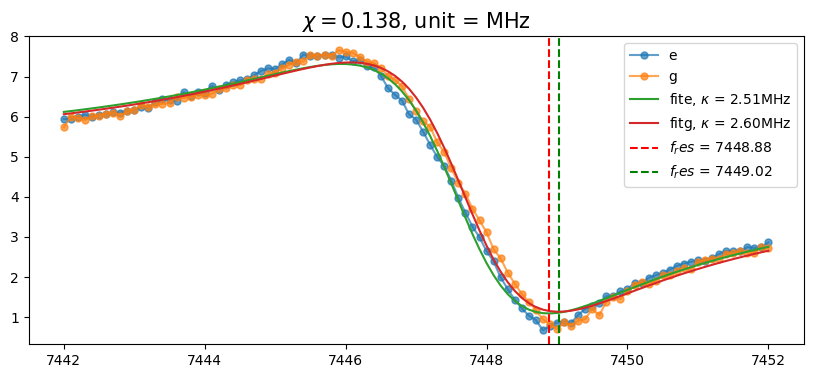

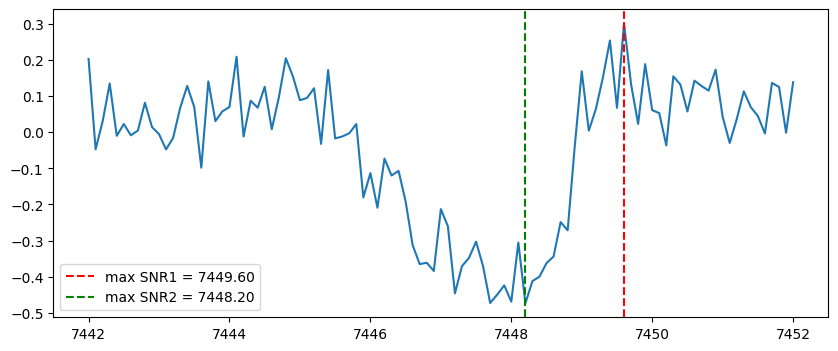

In [79]:
pyavg = 10
run_cfg['ro_len'] = 0.5

prog = Dispersive_e(soccfg, reps=100, final_delay=40, cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
dispersive_e = (iq_list[0][0].dot([1,1j]))

prog = Dispersive_g(soccfg, reps=100, final_delay=40, cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
dispersive_g = (iq_list[0][0].dot([1,1j]))
dispersive_analyze(freqs, dispersive_e, dispersive_g)

# pulse train

In [152]:
class PulseTrain(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        for i in range(cfg['iter']):
            if i==0:
                pass
            else:
                self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
                self.delay_auto(0.0)
                self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
                self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [156]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 200


config.update({'relax_delay':100, 'qb_pulse_style':'arb', 'sigma':0.2, 'flat_top_len':0.1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
     }
run_cfg = {**config, **expt_cfg}

In [158]:
pyavg = 50
iterlsit = np.arange(0, 30, 2)

pulse_train=[]
for i in tqdm(iterlsit, desc='amp pulse train'):
    run_cfg['iter'] = i
    amp_rabi=PulseTrain(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = amp_rabi.acquire(soc, rounds=pyavg, progress=False, threshold=run_cfg['thresholds'])
    gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
    power_rabi = iq_list[0][0].dot([1,1j])
    pulse_train.append(power_rabi)

amp pulse train:   0%|          | 0/15 [00:00<?, ?it/s]

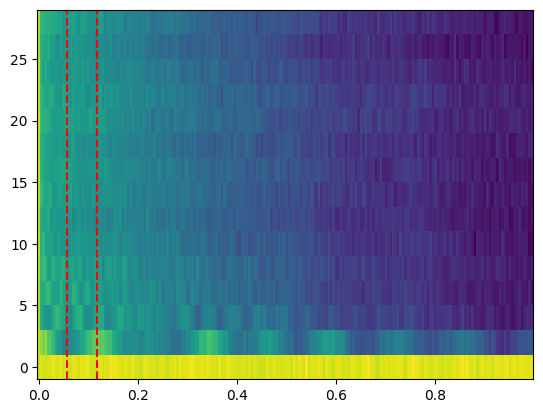

In [159]:
plt.pcolormesh(gains, iterlsit, np.abs(pulse_train))
plt.axvline(config['pi_gain'], color='red', linestyle='--', label='Pi Gain')
plt.axvline(config['pi2_gain'], color='red', linestyle='--', label='2Pi Gain')

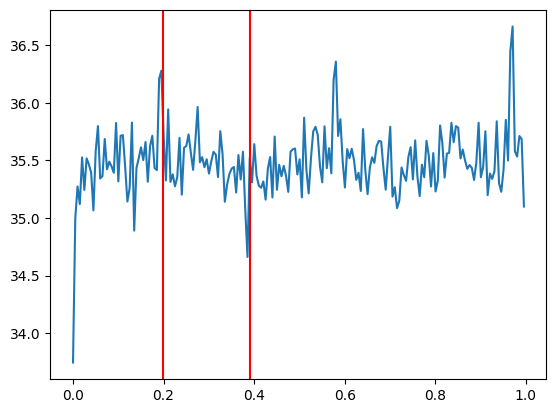

In [173]:
z=0
z2=0
for i in range(len(pulse_train)):
    z+=pulse_train[i]
run_cfg['iter']=0
amp_rabi=PulseTrain(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)

gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)

plt.plot(gains,np.abs(z))
plt.axvline(run_cfg['pi2_gain'],color='r')
plt.axvline(run_cfg['pi_gain'],color='r')

# ALL XY

In [135]:
class AllXY(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if cfg['allxy_gates'][0]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][0]}", t=0) 
        self.delay_auto(0.01) 
        if cfg['allxy_gates'][1]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][1]}", t=0) 
        
        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [136]:
sequence = [
    ("I", "I"),
    ("x180", "x180"),
    ("y180", "y180"),
    ("x180", "y180"),
    ("y180", "x180"),
    ("x90", "I"),
    ("y90", "I"),
    ("x90", "y90"),
    ("y90", "x90"),
    ("x90", "y180"),
    ("y90", "x180"),
    ("x180", "y90"),
    ("y180", "x90"),
    ("x90", "x180"),
    ("x180", "x90"),
    ("y90", "y180"),
    ("y180", "y90"),
    ("x180", "I"),
    ("y180", "I"),
    ("x90", "x90"),
    ("y90", "y90"),
]


  0%|          | 0/21 [00:00<?, ?it/s]

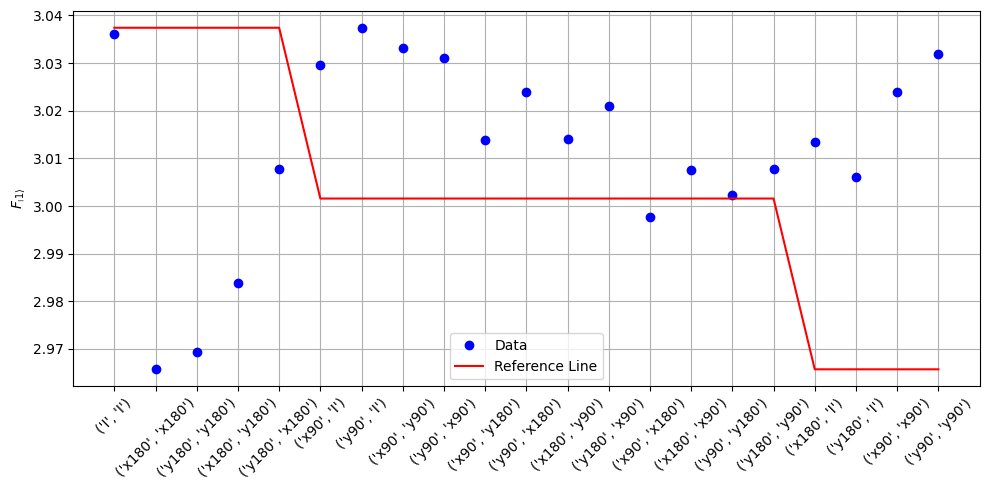

In [137]:
pyavg = 50

allxy_lst=[]
for gate in tqdm(sequence):
    run_cfg['allxy_gates'] = gate
    allxy=AllXY(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = allxy.acquire(soc, rounds=pyavg, progress=False, threshold=run_cfg['thresholds'])
    allxy_lst.append(iq_list[0][0].dot([1,1j]))

amp = np.abs(allxy_lst)
plt.figure(figsize=(10, 5))
plt.plot(amp, 'bo', label='Data')
plt.plot([np.max(amp)]*5 + [0.5*(np.max(amp)+np.min(amp))]*12 + [np.min(amp)]*4, 'r-', label='Reference Line')
plt.xticks(np.arange(len(sequence)), sequence, rotation=45)
plt.ylabel(r'$F_{\left|1\right\rangle}$')
plt.legend()
plt.tight_layout()
plt.grid(True) 
plt.show()

# Procress tomography (under test)

In [183]:
class RefIQ(AveragerProgramV2):
    def _initialize(self, cfg):
        qubit_ch = cfg['qubit_ch']
        res_ch = cfg['res_ch']
        ro_ch = cfg['ro_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        self.add_gauss(ch=res_ch, name="res_ramp", sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, style="flat_top", envelope="res_ramp", length=cfg['res_len'], freq=cfg['f_res'], phase=cfg['res_phase'], gain=cfg['res_gain'])
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

        # pulses
        for name, phase, gain in [('x180', 0, cfg['pi_gain']),
                                  ('x90', 0, cfg['pi2_gain']),
                                  ('y90', 90, cfg['pi2_gain'])]:
            self.add_pulse(ch=qubit_ch, name=name, style="arb", envelope="ramp", freq=cfg['f_ge'], phase=phase, gain=gain)

    def _body(self, cfg):
        sequence = cfg["seq"]  # e.g. ['x180', 'x90']
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        for name in sequence:
            self.pulse(ch=cfg['qubit_ch'], name=name, t=0)
            self.delay_auto(0.01)
        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [186]:
ref_states = {
    'iq_0': [],  # |0>
    'iq_1': ['x180'],  # |1>
    'iq_p': ['x90'],  # |+>
    'iq_m': ['x180', 'x90'],  # |−>
    'iq_ip': ['y90'],  # |+i>
    'iq_im': ['x180', 'y90'],  # |−i>
}
run_cfg = config
ref_points = {}
pyavg = 200
for name, seq in ref_states.items():
    run_cfg['seq'] = seq
    prog = RefIQ(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = prog.acquire(soc, rounds=pyavg)

    ref_points[name] = iq_list[0][0].dot([1, 1j])  # Convert to complex IQ data
    
reference_points = {
    'Z': (ref_points['iq_0'], ref_points['iq_1']),
    'X': (ref_points['iq_p'], ref_points['iq_m']),
    'Y': (ref_points['iq_ip'], ref_points['iq_im'])
}


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [187]:
class QPT(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="y90m", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=-90,
                    gain=cfg['pi2_gain'], 
                    )
            
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
            self.add_pulse(ch=qubit_ch, name="y90m", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=-90,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
    def _body(self, cfg):
        """
        QPT Measurement Body for QICK

        cfg:
            prep_state: 'I', 'X90', 'Y90', 'X180' -> 用來準備初態
            process: 'I', 'X90', 'Y90'            -> 要 character 的量子過程
            tomo_axis: 'Z', 'X', or 'Y'           -> 投影方向
            qubit_ch, res_ch, ro_ch, trig_time   -> 設備參數
        """
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)

        # --- Step 1: Initialize the input state ---
        prep = cfg["prep_state"]
        if prep == "I":
            pass  # |0⟩
        elif prep == "X180":
            self.pulse(ch=cfg['qubit_ch'], name="x180", t=0)  # |1⟩
            self.delay_auto(0.01)
        elif prep == "X90":
            self.pulse(ch=cfg['qubit_ch'], name="x90", t=0)   # |+⟩
            self.delay_auto(0.01)
        elif prep == "Y90":
            self.pulse(ch=cfg['qubit_ch'], name="y90", t=0)   # |+i⟩
            self.delay_auto(0.01)
        else:
            raise ValueError(f"Unknown prep_state: {prep}")

        # --- Step 2: Apply the process you want to characterize ---
        process = cfg["process"]
        if process == "I":
            pass
        elif process == "X90":
            self.pulse(ch=cfg['qubit_ch'], name="x90", t=0)
            self.delay_auto(0.01)
        elif process == "Y90":
            self.pulse(ch=cfg['qubit_ch'], name="y90", t=0)
            self.delay_auto(0.01)
        else:
            raise ValueError(f"Unknown process: {process}")

        # --- Step 3: Tomography axis projection ---
        tomo = cfg["tomo_axis"]
        if tomo == "I":
            pass  # |0⟩
        elif tomo == "X180":
            self.pulse(ch=cfg['qubit_ch'], name="x180", t=0)  # |1⟩
            self.delay_auto(0.01)
        elif tomo == "X90":
            self.pulse(ch=cfg['qubit_ch'], name="x90", t=0)   # |+⟩
            self.delay_auto(0.01)
        elif tomo == "Y90":
            self.pulse(ch=cfg['qubit_ch'], name="y90", t=0)   # |+i⟩
            self.delay_auto(0.01)
        else:
            raise ValueError(f"Unknown prep_state: {tomo}")

        # --- Step 4: Readout ---
        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [ ]:
from tqdm.auto import tqdm  

# define your prep states, processes, and tomography axes
prep_states = ['I', 'X90', 'Y90', 'X180']
processes = ['I', 'X90', 'Y90']
tomo_axes = ['I', 'X90', 'Y90', 'X180']

data_records = []
pyavg = 50
for prep in tqdm(prep_states, desc="Preparing States", leave=True):
    for proc in tqdm(processes, desc=f"Processing {prep}", leave=False):
        for axis in tqdm(tomo_axes, desc=f"Tomo_axes Axis {proc}", leave=False):
            run_cfg['prep_state'] = prep
            run_cfg['process'] = proc
            run_cfg['tomo_axis'] = axis

            qpt = QPT(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
            iq_list = qpt.acquire(soc, rounds=pyavg, progress=False)

            data_records.append({
                'prep': prep,
                'process': proc,
                'axis': axis,
                'iq': iq_list[0][0].dot([1, 1j])  # Convert to complex IQ data
            })


  0%|          | 0/4 [00:00<?, ?it/s]

Processing I:   0%|          | 0/3 [00:00<?, ?it/s]

Axis I:   0%|          | 0/4 [00:00<?, ?it/s]

Axis X90:   0%|          | 0/4 [00:00<?, ?it/s]

Axis Y90:   0%|          | 0/4 [00:00<?, ?it/s]

...

Axis Y90:   0%|          | 0/4 [00:00<?, ?it/s]

Processing X180:   0%|          | 0/3 [00:00<?, ?it/s]

Axis I:   0%|          | 0/4 [00:00<?, ?it/s]

Axis X90:   0%|          | 0/4 [00:00<?, ?it/s]

Axis Y90:   0%|          | 0/4 [00:00<?, ?it/s]

In [193]:
from tqdm import tqdm
import numpy as np

# 定義：準備態、欲重建的量子閘、tomography 軸
prep_states = ['I', 'X90', 'Y90', 'X180']
processes = ['I', 'X90', 'Y90']
tomo_axes = ['I', 'X90', 'Y90', 'X180']
tomo_map = {
    'I': 'Z',        # no gate -> Z projection
    'X90': 'X',      # Rx(π/2) → X 投影
    'Y90': 'Y',      # Ry(π/2) → Y 投影
    'X180': 'Z'      # Rx(π) → Z 投影, 對應 |1⟩
}

data_records = []

# 資料擷取
for prep in tqdm(prep_states, desc='Preparing QPT data'):
    for proc in processes:
        for axis in tomo_axes:
            run_cfg['prep_state'] = prep
            run_cfg['process'] = proc
            run_cfg['tomo_axis'] = axis

            qpt = QPT(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
            iq_list = qpt.acquire(soc, soft_avgs=pyavg, progress=False, threshold=run_cfg['thresholds'])

            data_records.append({
                'prep': prep,
                'process': proc,
                'axis': axis,
                'iq': iq_list[0][0].dot([1, 1j])  # 將 IQ 轉為 complex
            })

import numpy as np
from tqdm import tqdm

# Pauli 基底
I2 = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])
B = [I2, X, Y, Z]

# IQ 轉期望值
def iq_to_expectation(iq, i_ref, o_ref):
    delta = i_ref - o_ref
    proj = np.real((iq - o_ref) * np.conj(delta)) / np.abs(delta)**2
    return 2 * proj - 1

# Bloch vector 轉密度矩陣
def bloch_to_rho(bloch):
    return 0.5 * (I2 + bloch[0]*X + bloch[1]*Y + bloch[2]*Z)

# 從 IQ grouped 資料建立密度矩陣 grouped
def iq_grouped_to_rho_grouped(grouped, reference_points):
    output_rhos = {}
    for key, axes in grouped.items():
        if not all(k in axes for k in ['X', 'Y', 'Z']):
            print(f"Skipping {key}, missing axes")
            continue
        bloch = []
        for axis in ['X', 'Y', 'Z']:
            i_ref, o_ref = reference_points[axis]
            expect = iq_to_expectation(axes[axis], i_ref, o_ref)
            bloch.append(expect)
        output_rhos[key] = bloch_to_rho(bloch)
    return output_rhos

# 從 output_rhos 建立 input_rhos (prep, I)
def reconstruct_input_rhos(output_rhos, reference_points, prep_states):
    input_rhos = {}
    for prep in prep_states:
        key = (prep, 'I')
        rho = output_rhos.get(key)
        if rho is None:
            print(f"Warning: Missing output rho for {key}")
            continue
        input_rhos[prep] = rho
    return input_rhos

# χ 重建主函數
def reconstruct_chi(output_rhos, reference_points, prep_states, processes):
    input_rhos = reconstruct_input_rhos(output_rhos, reference_points, prep_states)
    chi_matrices = {}

    for process in tqdm(processes, desc='Reconstructing χ'):
        A_matrix_rows = []
        b_vector_elements = []

        for prep in prep_states:
            rho_in = input_rhos.get(prep)
            rho_out = output_rhos.get((prep, process))

            if rho_in is None or rho_out is None:
                print(f"Skipping (prep={prep}, process={process}) due to missing data")
                continue

            b_vector_elements.extend(rho_out.flatten(order='C'))

            for k in range(4):
                row = []
                for Bm in B:
                    for Bn in B:
                        vec_op = (Bm @ rho_in @ Bn.conj().T).flatten(order='C')
                        row.append(vec_op[k])
                A_matrix_rows.append(row)

        A_matrix = np.array(A_matrix_rows)
        b_vector = np.array(b_vector_elements)

        if A_matrix.shape[0] != len(b_vector) or A_matrix.shape[1] != 16:
            print(f"Warning: skipping {process} due to invalid shape A={A_matrix.shape}, b={b_vector.shape}")
            continue

        try:
            x, residuals, rank, s = np.linalg.lstsq(A_matrix, b_vector, rcond=None)
        except np.linalg.LinAlgError as e:
            print(f"LinAlgError during χ reconstruction: {e}")
            continue

        chi = x.reshape(4, 4)
        chi = 0.5 * (chi + chi.conj().T)  # 強制 Hermitian
        chi_matrices[process] = chi

    return chi_matrices
# 1. 建立 output_rhos
output_rhos = iq_grouped_to_rho_grouped(grouped, reference_points)

# 2. 重建 χ
chi_matrices = reconstruct_chi(output_rhos, reference_points, prep_states, processes)

# 3. 顯示結果
print("\nReconstruction complete. Chi matrices:")
for proc, chi_mat in chi_matrices.items():
    print(f"\n--- Process: {proc} ---")
    print(chi_mat)

Reconstructing χ: 100%|██████████| 3/3 [00:00<00:00, 429.98it/s]


Reconstruction complete. Chi matrices:

--- Process: I ---
[[ 1.00000000e+00+0.00000000e+00j  3.90643394e-17-3.77678288e-17j
   1.44811541e-16-3.50613539e-17j  1.47915851e-16+4.49240429e-17j]
 [ 3.90643394e-17+3.77678288e-17j  1.66330301e-17+0.00000000e+00j
  -1.54995062e-16-2.45369245e-16j -8.75462845e-18+1.14002084e-16j]
 [ 1.44811541e-16+3.50613539e-17j -1.54995062e-16+2.45369245e-16j
   1.88372211e-17+0.00000000e+00j -7.21829618e-17-7.54174403e-17j]
 [ 1.47915851e-16-4.49240429e-17j -8.75462845e-18-1.14002084e-16j
  -7.21829618e-17+7.54174403e-17j  1.07187648e-16+0.00000000e+00j]]

--- Process: X90 ---
[[ 1.95423847e+00+0.j          3.63673091e+00-0.0289477j
  -6.66437582e+00-4.76591692j  7.34105150e-02+0.05660906j]
 [ 3.63673091e+00+0.0289477j  -1.18131480e+00+0.j
  -9.17852526e-01-0.07341051j -4.72729752e+00-6.66437582j]
 [-6.66437582e+00+4.76591692j -9.17852526e-01+0.07341051j
   1.78970735e+00+0.j          4.09218387e-03-3.63673091j]
 [ 7.34105150e-02-0.05660906j -4.72729752e+

C:\Users\QEL\AppData\Local\Temp\ipykernel_12144\360229967.py:160: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0.05, 0, 1, 0.98]) # [left, bottom, right, top]


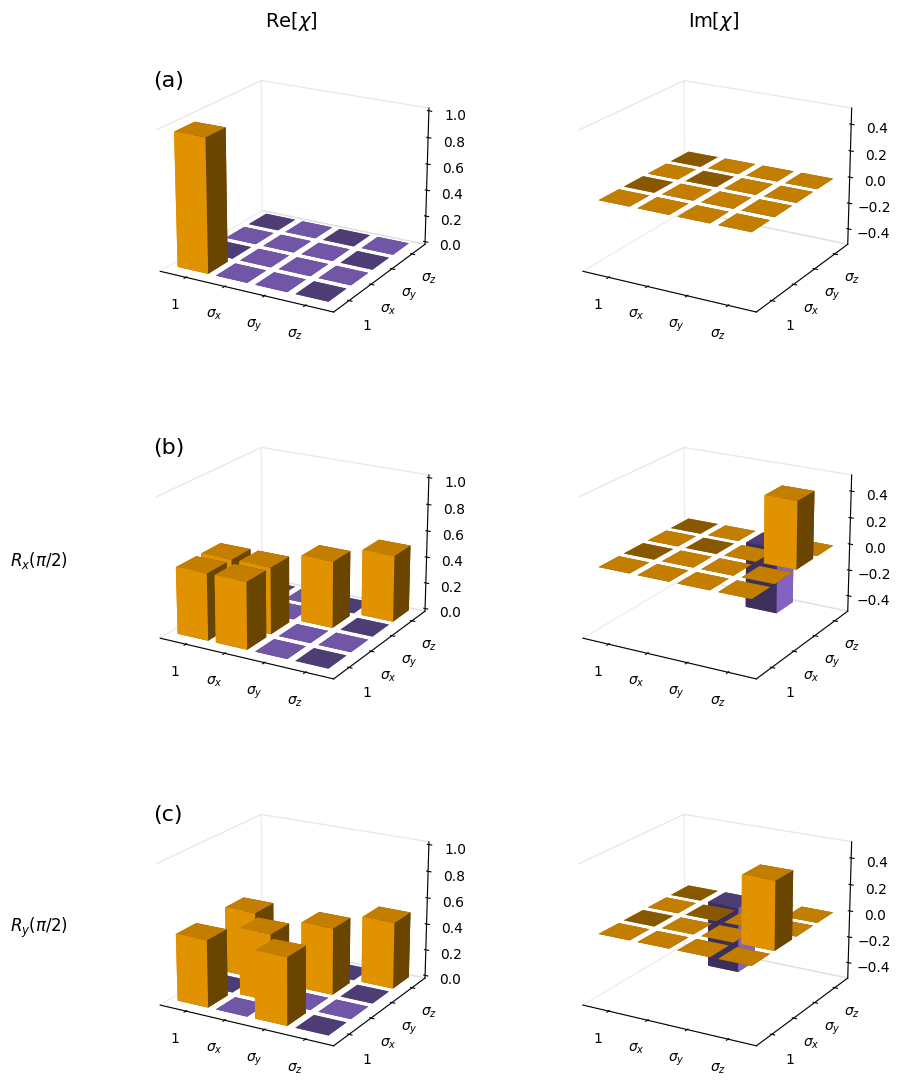

In [194]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # 導入 3D 繪圖工具

# ----------------------------------------------------------------------
# 假設 chi_matrices 已經由您的 QPT 重建程式碼計算得出
#
# 以下提供一個與您圖片視覺效果相似的範例 chi_matrices 數據，
# 請在實際運行時將其替換為您的真實數據！
#
# 注意：這些數值僅用於演示繪圖效果，不代表精確的理想 χ 矩陣。
# ----------------------------------------------------------------------
chi_matrices = {
    'I': np.array([
        [1.0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ], dtype=complex), # 與圖片 (a) Identity 閘的視覺效果匹配
    'Rx(π/2)': np.array([ # 與圖片 (b) Rx(π/2) 閘的視覺效果匹配
        [0.5, 0.5, 0, 0],
        [0.5, 0.5, 0, 0],
        [0, 0, 0.5, -0.5j],
        [0, 0, 0.5j, 0.5]
    ], dtype=complex),
    'Ry(π/2)': np.array([ # 與圖片 (c) Ry(π/2) 閘的視覺效果匹配
        [0.5, 0, 0.5, 0],
        [0, 0.5, 0, -0.5j],
        [0.5, 0, 0.5, 0],
        [0, 0.5j, 0, 0.5]
    ], dtype=complex),
}

# Pauli 基底的標籤，與圖片中的 '1', 'σx', 'σy', 'σz' 對應
pauli_labels = ['1', r'$\sigma_x$', r'$\sigma_y$', r'$\sigma_z$']

# 全局繪圖設定，調整以匹配參考圖片的風格
bar_width = 0.8 # 長條的寬度和深度
elev_angle = 20 # 3D 視圖的仰角 (elevation)
azim_angle = -60 # 3D 視圖的方位角 (azimuth)，調整以使 (0,0) 角靠近視角

# 確定需要多少行子圖 (每行為一個閘)
num_gates = len(chi_matrices)
fig_height_per_gate = 4.5 # 每行子圖的高度，可調整以控制整體圖片大小和間距

# 創建一個總圖，包含所有子圖
fig = plt.figure(figsize=(10, num_gates * fig_height_per_gate))

# 用於標記 (a), (b), (c) 的列表
panel_labels = ['(a)', '(b)', '(c)']
# 用於左側閘名稱的字典
gate_names = {'I': '', 'Rx(π/2)': r'$R_x(\pi/2)$', 'Ry(π/2)': r'$R_y(\pi/2)$'} # Full gate names for the left labels

# 子圖索引計數器 (從 1 開始)
subplot_idx = 1
# 閘的計數器 (從 0 開始，對應 panel_labels)
gate_counter = 0

for gate_key, chi in chi_matrices.items():
    # --- 繪製實部圖 ---
    # 添加 3D 子圖
    ax_real = fig.add_subplot(num_gates, 2, subplot_idx, projection='3d')

    # 獲取 χ 矩陣實部的扁平化值
    real_values = np.real(chi).ravel()
    
    # 根據值定義長條顏色：如果實部顯著為正 (>0.4)，則為橘色，否則為紫羅蘭色
    # 這個閾值可以根據您的實際數據調整，以匹配圖片的顏色邏輯
    colors_real = np.where(real_values > 0.4, 'orange', 'mediumpurple') 

    # 創建長條的 X, Y 座標網格
    xpos, ypos = np.meshgrid(range(4), range(4), indexing="ij")
    xpos = xpos.ravel()
    ypos = ypos.ravel()

    # 繪製 3D 長條圖
    ax_real.bar3d(xpos, ypos, np.zeros_like(real_values), bar_width, bar_width, real_values, color=colors_real, shade=True)

    # 如果是第一行，設置列標題 (Re[χ])
    if gate_counter == 0:
        ax_real.set_title(r"Re[$\chi$]", fontsize=14, loc='center', pad=10) # 列標題

    # 添加面板標籤 (a), (b), (c)
    ax_real.text2D(0.05, 0.9, panel_labels[gate_counter], transform=ax_real.transAxes, fontsize=16, va='top', ha='left')

    # 設定 Z 軸範圍和軸刻度
    ax_real.set_zlim(0, 1.0) # 固定實部 Z 軸範圍
    ax_real.set_xticks(np.arange(4) + bar_width/2) # 將刻度置於長條中心
    ax_real.set_yticks(np.arange(4) + bar_width/2)
    ax_real.set_xticklabels(pauli_labels) # 設定 X 軸標籤
    ax_real.set_yticklabels(pauli_labels) # 設定 Y 軸標籤

    # 設定視角
    ax_real.view_init(elev=elev_angle, azim=azim_angle)

    # 調整 3D 繪圖的背景窗格，使其只有底部網格線
    # 這裡的修改解決了 AttributeError
    ax_real.xaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0)) # 設置透明填充
    ax_real.yaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
    ax_real.zaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
    
    ax_real.xaxis.pane.set_edgecolor('lightgray') # 設定 X 軸面板邊緣顏色 (網格線)
    ax_real.yaxis.pane.set_edgecolor('lightgray') # 設定 Y 軸面板邊緣顏色 (網格線)
    ax_real.zaxis.pane.set_edgecolor('lightgray') # 設定 Z 軸面板邊緣顏色 (網格線)
    ax_real.grid(False) # 關閉 matplotlib 默認的 3D 網格，只保留 pane 的邊緣線

    subplot_idx += 1

    # --- 繪製虛部圖 ---
    ax_imag = fig.add_subplot(num_gates, 2, subplot_idx, projection='3d')

    # 獲取 χ 矩陣虛部的扁平化值
    imag_values = np.imag(chi).ravel()

    # 根據符號定義長條顏色：虛部非負為橘色，負數為紫羅蘭色
    colors_imag = np.where(imag_values >= 0, 'orange', 'mediumpurple')

    # 繪製 3D 長條圖
    ax_imag.bar3d(xpos, ypos, np.zeros_like(imag_values), bar_width, bar_width, imag_values, color=colors_imag, shade=True)

    # 如果是第一行，設置列標題 (Im[χ])
    if gate_counter == 0:
        ax_imag.set_title(r"Im[$\chi$]", fontsize=14, loc='center', pad=10) # 列標題
        
    # 設定 Z 軸範圍和軸刻度
    ax_imag.set_zlim(-0.5, 0.5) # 固定虛部 Z 軸範圍
    ax_imag.set_xticks(np.arange(4) + bar_width/2)
    ax_imag.set_yticks(np.arange(4) + bar_width/2)
    ax_imag.set_xticklabels(pauli_labels)
    ax_imag.set_yticklabels(pauli_labels)

    # 設定視角
    ax_imag.view_init(elev=elev_angle, azim=azim_angle)

    # 調整 3D 繪圖的背景窗格，使其只有底部網格線
    # 這裡的修改解決了 AttributeError
    ax_imag.xaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0)) # 設置透明填充
    ax_imag.yaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
    ax_imag.zaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))

    ax_imag.xaxis.pane.set_edgecolor('lightgray') # 設定 X 軸面板邊緣顏色 (網格線)
    ax_imag.yaxis.pane.set_edgecolor('lightgray') # 設定 Y 軸面板邊緣顏色 (網格線)
    ax_imag.zaxis.pane.set_edgecolor('lightgray') # 設定 Z 軸面板邊緣顏色 (網格線)
    ax_imag.grid(False) # 關閉 matplotlib 默認的 3D 網格

    subplot_idx += 1
    
    # 在當前行的左側添加閘的名稱 (使用 figure 座標)
    # 獲取當前實部子圖的位置框 (用於計算垂直中心)
    bbox = ax_real.get_position()
    # 計算當前行子圖的垂直中心
    y_center = bbox.y0 + bbox.height / 2
    
    # 在 figure 級別添加文字，位置 (0.02, y_center) 表示離左邊 2% 處，垂直居中
    fig.text(0.02, y_center, gate_names[gate_key], fontsize=12, va='center', ha='left')

    gate_counter += 1

# 調整整體佈局，特別是左邊距，為閘名稱留出空間
plt.tight_layout(rect=[0.05, 0, 1, 0.98]) # [left, bottom, right, top]
plt.show()

# tomography (under test)

In [206]:
class StateTomography(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
    

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="x180", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0, gain=cfg['pi_gain'])
        self.add_pulse(ch=qubit_ch, name="x90", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0, gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="y90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=-90, gain=cfg['pi2_gain'])

    def _body(self, cfg):
        axis = cfg["tomo_axis"]  # 'Z', 'X', or 'Y'

        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        ## test pulse check tomography result###
        self.pulse(ch=cfg['qubit_ch'], name="y90m", t=0)
        self.delay_auto(0.05)
        #########################################
        
        # Apply axis-specific pre-rotation
        if axis == "X":
            self.pulse(ch=cfg['qubit_ch'], name="x90", t=0)
            self.delay_auto(0.01)
        elif axis == "Y":
            self.pulse(ch=cfg['qubit_ch'], name="y90m", t=0)
            self.delay_auto(0.01)
        elif axis == "Z":
            pass  # No rotation

        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [207]:
run_cfg

{'res_ch': 0,
 'ro_ch': 0,
 'qubit_ch': 14,
 'f_res': 5798.138,
 'res_len': 10,
 'res_phase': 0,
 'res_gain': 0.4,
 'res_sigma': 0.004,
 'trig_time': 0.45,
 'ro_len': 10,
 'relax_delay': 100,
 'thresholds': None,
 'qb_pulse_style': 'arb',
 'f_ge': 4578.78,
 'nqz': 2,
 'qubit_gain': 0.1,
 'probe_len': 5,
 'flat_top_len': 0.1,
 'pi_gain': 0.390538,
 'pi2_gain': 0.198899,
 'qubit_phase': 0,
 'sigma': 0.02,
 'ramsey_freq': 3,
 'qmixer_freq': 4578.78,
 'seq': ['x180', 'y90'],
 'prep_state': 'X180',
 'process': 'Y90',
 'tomo_axis': 'Z',
 'allxy_gates': ('y90', 'y90')}

In [208]:
pyavg = 50

tomo_data = {'X': [], 'Y': [], 'Z': []}

for axis in tqdm(['X', 'Y', 'Z'], desc='State Tomography'):
    run_cfg['tomo_axis'] = axis
    prog = StateTomography(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)

    iq_list = prog.acquire(soc, rounds=pyavg, progress=False)

    iq = iq_list[0][0].dot([1, 1j])
    tomo_data[axis] = iq

State Tomography: 100%|██████████| 3/3 [00:02<00:00,  1.09it/s]


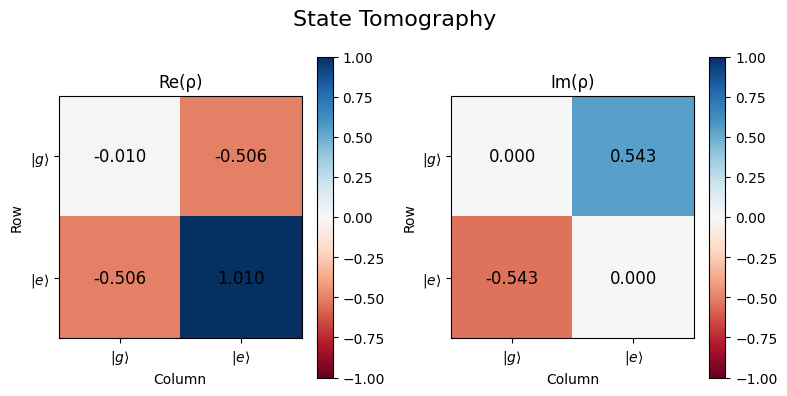

In [210]:
ex = np.real(tomo_data['X'])
ey = np.real(tomo_data['Y'])
ez = np.real(tomo_data['Z'])

# Pauli 矩陣
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])


rho = 0.5 * (I + ex * X + ey * Y + ez * Z)




fig, ax = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("State Tomography", fontsize=16)
im0 = ax[0].imshow(np.real(rho), vmin=-1, vmax=1, cmap='RdBu')
im1 = ax[1].imshow(np.imag(rho), vmin=-1, vmax=1, cmap='RdBu')
ax[0].set_title("Re(ρ)")
ax[1].set_title("Im(ρ)")
tick_labels = [r"$|g\rangle$", r"$|e\rangle$"]
for a in ax:
    a.set_xticks([0, 1])
    a.set_yticks([0, 1])
    a.set_xticklabels(tick_labels)
    a.set_yticklabels(tick_labels)
    a.set_xlabel("Column")
    a.set_ylabel("Row")
for i in range(2):
    for j in range(2):
        real_val = np.real(rho[i, j])
        imag_val = np.imag(rho[i, j])
        ax[0].text(j, i, f"{real_val:.3f}", ha='center', va='center', color='black', fontsize=12)
        ax[1].text(j, i, f"{imag_val:.3f}", ha='center', va='center', color='black', fontsize=12)

plt.colorbar(im0, ax=ax[0])
plt.colorbar(im1, ax=ax[1])
plt.tight_layout()
plt.show()

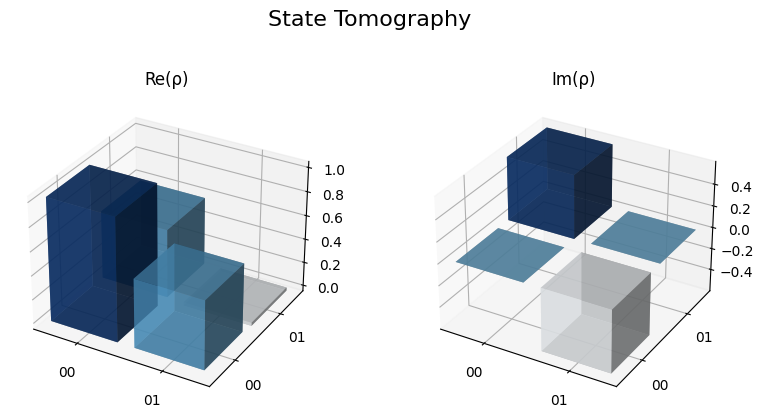

In [201]:
from mpl_toolkits.mplot3d import Axes3D

def plot_density_matrix_3d_both(rho, title="Density Matrix"):
    """
    Plot Re(ρ) and Im(ρ) as side-by-side 3D bar plots.
    
    Parameters:
    - rho: 2D numpy array representing the density matrix
    - title: title string for the entire figure
    """
    n = rho.shape[0]
    xpos, ypos = np.meshgrid(np.arange(n), np.arange(n))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)
    dx = dy = 0.8 * np.ones_like(zpos)

    fig = plt.figure(figsize=(8, 5))
    fig.suptitle(title, fontsize=16)

    for i, part in enumerate(["real", "imag"]):
        ax = fig.add_subplot(1, 2, i+1, projection='3d')

        if part == "real":
            dz = np.real(rho).flatten()
            label = "Re(ρ)"
        else:
            dz = np.imag(rho).flatten()
            label = "Im(ρ)"

        colors = plt.cm.Blues((dz - dz.min()) / (dz.ptp() + 1e-9))  # normalize to [0,1]
        zpos_bar = np.zeros_like(dz)
        dz_bar = dz.copy()

        for i in range(len(dz)):
            if dz[i] < 0:
                zpos_bar[i] = dz[i]  
                dz_bar[i] = -dz[i]  

        ax.bar3d(xpos, ypos, zpos_bar, dx, dy, dz_bar, color=colors, zsort='average', alpha=0.7)

        ax.set_xticks(np.arange(n) + 0.4)
        ax.set_yticks(np.arange(n) + 0.4)
        ax.set_xticklabels([f"{i:02b}" for i in range(n)])
        ax.set_yticklabels([f"{i:02b}" for i in range(n)])
        ax.set_title(label)

    plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3)
    plt.show()
    plt.show()
plot_density_matrix_3d_both(rho, title="State Tomography")

# RB

In [ ]:
class RB(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            ## X pulse ##
            self.add_pulse(ch=qubit_ch, name="X", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="-X", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="X/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="-X/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=-cfg['pi2_gain'], 
                    )
            ## Y pulse ##
            self.add_pulse(ch=qubit_ch, name="Y", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="-Y", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="Y/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="-Y/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=-cfg['pi2_gain'], 
                    )
            
        # elif cfg['qb_pulse_style']=='flat_top':
        #      ## X pulse ##
        #     self.add_pulse(ch=qubit_ch, name="x180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=0,
        #                 gain=cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="-x180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=0,
        #                 gain=-cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="x90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=0,
        #             gain=cfg['pi2_gain'], 
        #             length = cfg['flat_top_len'],
        #             )
        #     self.add_pulse(ch=qubit_ch, name="-x90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=0,
        #             gain=-cfg['pi2_gain'], 
        #             length = cfg['flat_top_len'],
        #             )
        #     ## Y pulse ##
        #     self.add_pulse(ch=qubit_ch, name="y180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=-90,
        #                 gain=cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="-y180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=-90,
        #                 gain=-cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="y90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=-90,
        #             gain=cfg['pi2_gain'],
        #             length = cfg['flat_top_len'], 
        #             )
        #     self.add_pulse(ch=qubit_ch, name="-y90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=-90,
        #             gain=-cfg['pi2_gain'],
        #             length = cfg['flat_top_len'], 
        #             )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        for i in self.cfg['gate_seq']:
            if i=='I' or i=='-I':
                # self.delay_auto(cfg['sigma']*5)
                pass
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name=f"{i}", t=0) 
                self.delay_auto(0.0)

        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
import numpy as np

"""
Define matrices representing (all) Clifford gates for single
qubit in the basis of Z, X, Y, -Z, -X, -Y, indicating
where on the 6 cardinal points of the Bloch sphere the
+Z, +X, +Y axes go after each gate. Each Clifford gate
can be uniquely identified just by checking where +X and +Y
go.
"""
clifford_1q = dict()
# clifford_1q["Z"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 0, 0, 1, 0, 0],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#     ]
# )
clifford_1q["X"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
    ]
)
clifford_1q["Y"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#     ]
# )
clifford_1q["X/2"] = np.matrix(
    [
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
    ]
)
clifford_1q["Y/2"] = np.matrix(
    [
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["-Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#     ]
# )
clifford_1q["-X/2"] = np.matrix(
    [
        [0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0],
    ]
)
clifford_1q["-Y/2"] = np.matrix(
    [
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
identity = np.diag([1] * 6)
clifford_1q["I"] = identity


# Read pulse as a matrix product acting on state (meaning apply pulses in reverse order of the tuple)
# two_step_pulses = [
#     ("X", "Z/2"),
#     ("X/2", "Z/2"),
#     ("-X/2", "Z/2"),
#     ("Y", "Z/2"),
#     ("Y/2", "Z/2"),
#     ("-Y/2", "Z/2"),
#     ("X", "Z"),
#     ("X/2", "Z"),
#     ("-X/2", "Z"),
#     ("Y", "Z"),
#     ("Y/2", "Z"),
#     ("-Y/2", "Z"),
#     ("X", "-Z/2"),
#     ("X/2", "-Z/2"),
#     ("-X/2", "-Z/2"),
#     ("Y", "-Z/2"),
#     ("Y/2", "-Z/2"),
#     ("-Y/2", "-Z/2"),
# ]

step_pulses = [
    ("Y/2", "X"),
    ("Y/2", "X/2"),
    ("X/2", "-Y/2", "-X/2"),
    ("-X/2", "-Y/2"),
    ("Y/2", "-X/2"),
    ("-X/2", "Y/2", "-X/2"),
    ("X/2", "Y/2"),
    ("-Y/2", "X"),
    ("-X/2", "Y"),
    ("-Y/2", "-X/2"),
    ("X/2", "Y/2", "X/2"),
    ("-X/2", "Y/2"),
    ("X", "Y"),
    ("X/2", "Y"),
    ("-Y/2", "X/2"),
    ("X/2", "Y/2", "-X/2"),
    ("X/2", "-Y/2"),
]

for pulse in step_pulses:
    new_mat = clifford_1q[pulse[0]]
    for p in pulse[1:]:
        new_mat = new_mat @ clifford_1q[p]
    repeat = False
    # Make sure there are no repeats
    for existing_pulse_name, existing_pulse in clifford_1q.items():
        if np.array_equal(new_mat, existing_pulse):
            print("found repeat", pulse, existing_pulse_name)
            repeat = True
    if not repeat:
        clifford_1q[pulse[0] + "," + ",".join(pulse[1:])] = new_mat
clifford_1q_names = list(clifford_1q.keys())
assert (
    len(clifford_1q_names) == 24
), f"you have {len(clifford_1q_names)} elements in your Clifford group instead of 24!"
# print(len(clifford_1q_names), "elements in clifford_1q")
# print(clifford_1q_names)

# Get the average number of X/2 gates per Clifford gate
count = 0
for n in range(len(clifford_1q_names)):  # n is index in clifford_1q_names
    gates = clifford_1q_names[n].split(",")
    for gate in gates:
        # print(gate)
        if gate == "I" or "Z" in gate:
            continue
        if "/2" in gate:
            count += 1
            # print("added 1 to count")
        else:
            count += 2
            # print("added 2 to count")
# print("Average number of X/2 gates per Clifford gate:", count / len(clifford_1q_names))

for name, matrix in clifford_1q.items():
    z_new = np.argmax(matrix[:, 0])  # +Z goes to row where col 0 is 1
    x_new = np.argmax(matrix[:, 1])  # +X goes to row where col 1 is 1
    # print(name, z_new, x_new)
    clifford_1q[name] = (matrix, (z_new, x_new))


def gate_sequence(rb_depth, pulse_n_seq=None, debug=False):
    """
    Generate RB forward gate sequence of length rb_depth as a list of pulse names;
    also return the Clifford gate that is equivalent to the total pulse sequence.
    The effective inverse is pi phase + the total Clifford.
    Optionally, provide pulse_n_seq which is a list of the indices of the Clifford
    gates to apply in the sequence.
    """
    if pulse_n_seq is None:
        pulse_n_seq = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_name_seq = [clifford_1q_names[n] for n in pulse_n_seq]
    if debug:
        print("pulse seq", pulse_name_seq)
    psi_nz = np.matrix([[1, 0, 0, 0, 0, 0]]).transpose()
    psi_nx = np.matrix([[0, 1, 0, 0, 0, 0]]).transpose()
    for n in pulse_n_seq:  # n is index in clifford_1q_names
        gates = clifford_1q_names[n].split(",")
        for gate in reversed(gates):  # Apply matrices from right to left of gates
            psi_nz = clifford_1q[gate][0] @ psi_nz
            psi_nx = clifford_1q[gate][0] @ psi_nx
    psi_nz = psi_nz.flatten()
    psi_nx = psi_nx.flatten()
    if debug:
        print("+Z axis after seq:", psi_nz, "+X axis after seq:", psi_nx)

    total_clifford = None
    if np.argmax(psi_nz) == 0:
        total_clifford = "I"
    else:
        for clifford in clifford_1q_names:  # Get the clifford equivalent to the total seq
            if clifford_1q[clifford][1] == (np.argmax(psi_nz), np.argmax(psi_nx)):
                # z_new, x_new = clifford_1q[clifford][1]
                # if z_new == np.argmax(psi_nz):
                total_clifford = clifford
                break
    assert total_clifford is not None, f"Failed to invert gate sequence! {pulse_name_seq} which brings +Z to {psi_nz}"

    if debug:
        total_clifford_mat = clifford_1q[total_clifford][0]
        print("Total gate matrix:\n", total_clifford_mat)

    return pulse_name_seq, total_clifford


def interleaved_gate_sequence(rb_depth, gate_char: str, debug=False):
    """
    Generate RB gate sequence with rb_depth random gates interleaved with gate_char
    Returns the total gate list (including the interleaved gates) and the total
    Clifford gate equivalent to the total pulse sequence.
    """
    pulse_n_seq_rand = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_n_seq = []
    assert gate_char in clifford_1q_names
    n_gate_char = clifford_1q_names.index(gate_char)
    if debug:
        print("n gate char:", n_gate_char, clifford_1q_names[n_gate_char])
    for n_rand in pulse_n_seq_rand:
        pulse_n_seq.append(n_rand)
        pulse_n_seq.append(n_gate_char)
    return gate_sequence(len(pulse_n_seq), pulse_n_seq=pulse_n_seq, debug=debug)

def expand_full_sequence(pulse_name_seq, total_clifford):
    """
    Expand a full pulse_name_seq into the actual flat play sequence, 
    handling normal and inverse gates correctly.

    Args:
        pulse_name_seq : list of str
            e.g., ['X/2', 'X/2', 'X/2,-Y/2,-X/2', 'X/2']
        total_clifford : str
            e.g., 'Y/2,-X/2'

    Returns:
        list of str
            Final flat sequence to be played on hardware, with each gate separately listed
    """
    full_sequence = []

    # Expand normal pulse names (right-to-left)
    for name in pulse_name_seq:
        gates = name.split(",")
        for g in reversed(gates):   # right-to-left
            full_sequence.append(g)

    # Expand total_clifford separately (left-to-right, inverse)
    for gate in total_clifford.split(","):
        neg = "-" in gate
        neg = not neg  # inverse要翻轉正負號

        if neg:
            if "-" not in gate:
                gate = "-" + gate
        else:
            if "-" in gate:
                gate = gate.replace("-", "")

        full_sequence.append(gate)

    # 最後做一次展平：如果某個gate裡還有逗號，就切開
    final_sequence = []
    for item in full_sequence:
        if "," in item:
            final_sequence.extend(item.split(","))
        else:
            final_sequence.append(item)

    return final_sequence


In [ ]:
pyavg = 150
max_circuit_depth = 201
delta_clifford = 20
x = np.arange(1, max_circuit_depth, delta_clifford)
number_sample = 60

In [ ]:
rb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        pulse_name_seq, total_clifford = gate_sequence(i, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)

        run_cfg['gate_seq'] = full_sequence
        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))

    rb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

KeyboardInterrupt: 

Fitted p = 97.986036 ± 0.524751
Error per Clifford (EPC)% = 3.287326 ± 0.262376


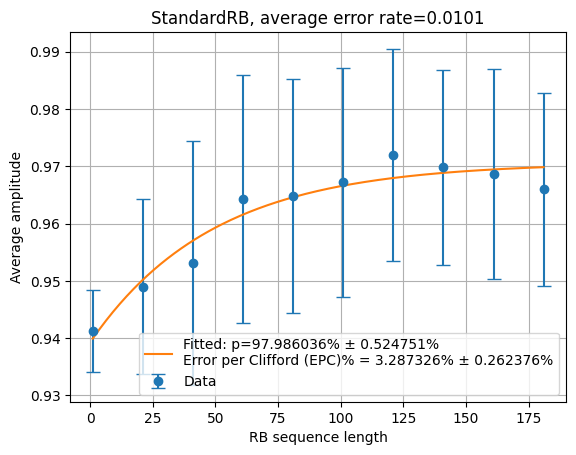

In [ ]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
std_r_avg = np.abs(np.mean(rb_result, axis=1))
std_r_std = np.abs(np.std(rb_result, axis=1))

pOpt, pCov = fitrb(x, std_r_avg)

std_p_fit = pOpt[0]
std_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {std_p_fit*100:.6f} ± {std_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(x, std_r_avg, yerr=std_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={std_p_fit*100:.6f}% ± {std_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
# plt.xscale('log')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'StandardRB, average error rate={rb_error(std_p_fit,2):.4f}')
# plt.title('InterleavedRB')
plt.grid(True)
plt.legend()
plt.show()

## interleve

In [ ]:
sxrb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        gate_char = "X/2"
        pulse_name_seq, total_clifford = interleaved_gate_sequence(i, gate_char=gate_char, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)
        run_cfg['gate_seq'] = full_sequence

        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))
    sxrb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 97.383151 ± 1.517795
Error per Clifford (EPC)% = 3.287326 ± 0.758897


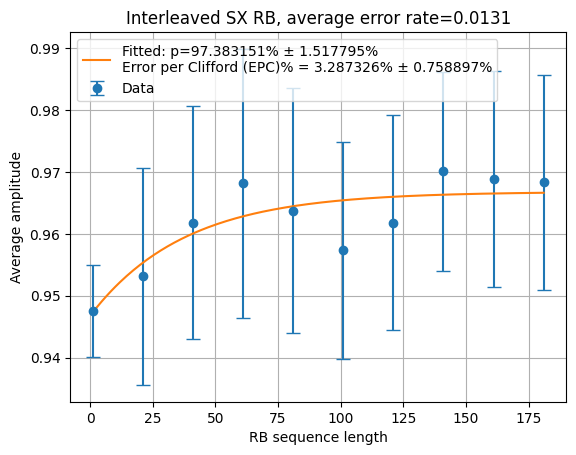

In [ ]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sx_r_avg = np.abs(np.mean(sxrb_result, axis=1))
sx_r_std = np.abs(np.std(sxrb_result, axis=1))

pOpt, pCov = fitrb(x, sx_r_avg)

sx_p_fit = pOpt[0]
sx_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {sx_p_fit*100:.6f} ± {sx_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(x, sx_r_avg, yerr=sx_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={sx_p_fit*100:.6f}% ± {sx_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'Interleaved SX RB, average error rate={rb_error(sx_p_fit,2):.4f}')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
xrb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        gate_char = "X"
        pulse_name_seq, total_clifford = interleaved_gate_sequence(i, gate_char=gate_char, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)
        run_cfg['gate_seq'] = full_sequence

        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))
    xrb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 99.043067 ± 0.433301
Error per Clifford (EPC)% = 3.287326 ± 0.216651


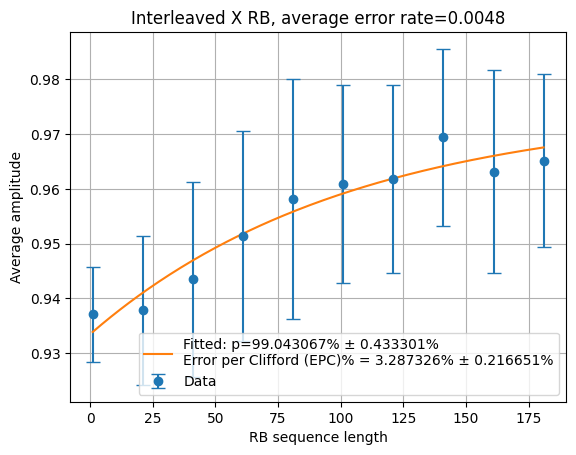

In [ ]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
x_r_avg = np.abs(np.mean(xrb_result, axis=1))
x_r_std = np.abs(np.std(xrb_result, axis=1))

pOpt, pCov = fitrb(x, x_r_avg)

x_p_fit = pOpt[0]
x_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {x_p_fit*100:.6f} ± {x_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)

plt.errorbar(x, x_r_avg, yerr=x_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={x_p_fit*100:.6f}% ± {x_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'Interleaved X RB, average error rate={rb_error(x_p_fit,2):.4f}')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print(rb_gate_fidelity(std_p_fit, sx_p_fit, 2, std_p_fit_err, x_p_fit_err))
print(rb_gate_fidelity(std_p_fit, x_p_fit, 2, std_p_fit_err, x_p_fit_err))

(0.9969236150141217, 0.01706325273371956)
(1.0053937832013502, 0.025533420920948124)


# RB qiskit

In [ ]:
class RB(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            ## X pulse ##
            self.add_pulse(ch=qubit_ch, name="rx(pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="rx(-pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="rx(pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="rx(-pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=-cfg['pi2_gain'], 
                    )
            ## Y pulse ##
            self.add_pulse(ch=qubit_ch, name="ry(pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="ry(-pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="ry(pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="ry(-pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=-cfg['pi2_gain'], 
                    )


    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        for i in self.cfg['gate_seq']:
            if i=='barrier':
                pass
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name=f"{i}", t=0) 
                self.delay_auto(0.0)

        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
exp = InterleavedRB(SXGate(), [0], [100], num_samples=10)
circs = exp.circuits()
circ = circs[0]
qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
# qasm.draw()
pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)
matches = re.findall(pattern, qasm_str)
len(matches)

302

In [ ]:
from qiskit import transpile
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit.circuit.library import XGate, SXGate
from qiskit import qasm3, QuantumCircuit, QuantumRegister, ClassicalRegister
import re

# xdata = np.unique(np.logspace(0.4, 3, 10).astype(int))
xdata = np.arange(1, 151, 10)
ydata_list = np.arange(50)

pyavg = 100
rblist_len = []

for i in tqdm(xdata, desc='depth'):
    rblist = []

    exp = StandardRB([0], [i], num_samples=len(ydata_list))
    # exp = InterleavedRB(XGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    rblist_len.append(rblist)


depth:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

...

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

Fitted p = 95.50 ± 0.14
Error per Clifford (EPC)% = 2.25 ± 0.07


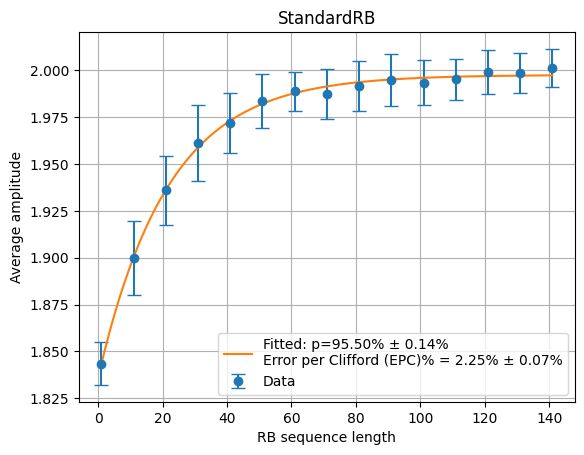

In [ ]:
r_avg = np.abs(np.mean(rblist_len, axis=1))
r_std = np.abs(np.std(rblist_len, axis=1))

pOpt, pCov = fitrb(xdata, r_avg)

p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(xdata), np.max(xdata), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(xdata, r_avg, yerr=r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
# plt.xscale('log')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('StandardRB')
# plt.title('InterleavedRB')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from qiskit import transpile
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit.circuit.library import XGate, SXGate
from qiskit import qasm3, QuantumCircuit, QuantumRegister, ClassicalRegister
import re

xdata = np.unique(np.logspace(0.4, 2.5, 50).astype(int))
xdata = np.arange(1, 201, 10)
ydata_list = np.arange(15)

pyavg = 100

std_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    exp = StandardRB([0], [i], num_samples=len(ydata_list))
    # exp = InterleavedRB(XGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    std_rblist_len.append(rblist)

x_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    # exp = StandardRB([0], [i], num_samples=len(ydata_list))
    exp = InterleavedRB(XGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    x_rblist_len.append(rblist)

sx_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    # exp = StandardRB([0], [i], num_samples=len(ydata_list))
    exp = InterleavedRB(SXGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    sx_rblist_len.append(rblist)


depth:   0%|          | 0/20 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

...

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
np.savez('stdrb.npz', x=xdata, y=std_rblist_len)
np.savez('xrb.npz', x=xdata, y=x_rblist_len)
np.savez('sxrb.npz', x=xdata, y=sx_rblist_len)

In [ ]:
std = np.load('rb.npz')
xrb = np.load('xrb.npz')
sxrb = np.load('sxrb.npz')

Fitted std: p = 99.97 ± 0.39
Error per Clifford (EPC)% = 0.02 ± 0.19


<Figure size 800x600 with 0 Axes>

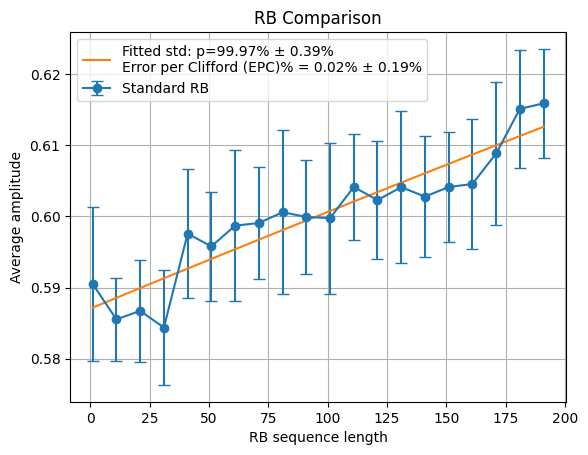

Fitted x: p = 99.54 ± 0.32
Error per Clifford (EPC)% = 0.23 ± 0.16


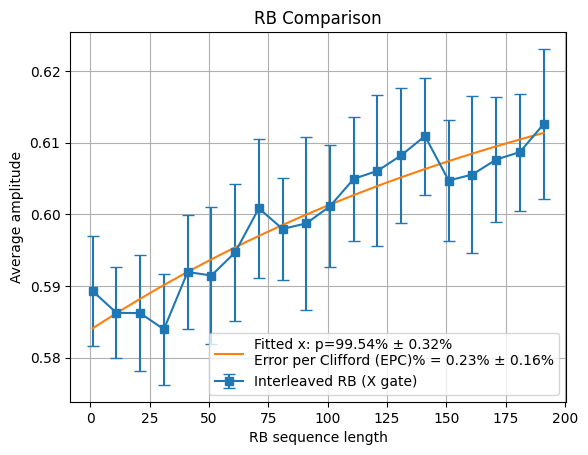

Fitted sx: p = 98.91 ± 0.41
Error per Clifford (EPC)% = 0.55 ± 0.21


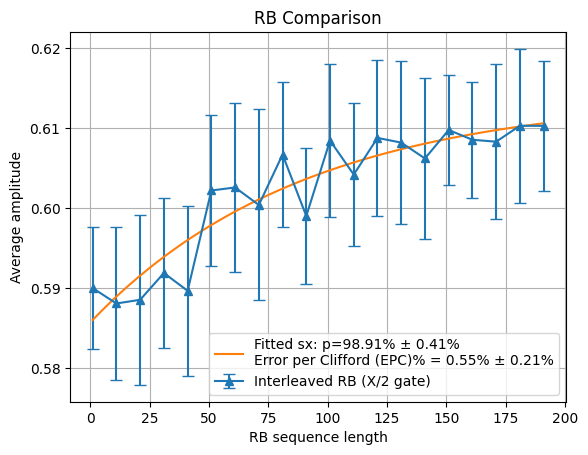

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
r_avg = np.abs(np.mean(std_rblist_len, axis=1))
r_std = np.abs(np.std(std_rblist_len, axis=1))
xrb_avg = np.abs(np.mean(x_rblist_len, axis=1))
xrb_err = np.abs(np.std(x_rblist_len, axis=1))
sxrb_avg = np.abs(np.mean(sx_rblist_len, axis=1))
sxrb_err = np.abs(np.std(sx_rblist_len, axis=1))

sequence_len = xdata
# rb_avg = std['y']
# rb_err = std['sigma']

# xrb_avg = xrb['y']
# xrb_err = xrb['sigma']

# sxrb_avg = sxrb['y']
# sxrb_err = sxrb['sigma']

plt.figure(figsize=(8,6))
plt.figure()
pOpt, pCov = fitrb(sequence_len, r_avg)
p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted std: p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, r_avg, yerr=r_std, fmt='o-', capsize=4, label='Standard RB')
plt.plot(xfit, yfit, '-', label=f'Fitted std: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
pOpt, pCov = fitrb(sequence_len, xrb_avg)
p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted x: p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, xrb_avg, yerr=xrb_err, fmt='s-', capsize=4, label='Interleaved RB (X gate)')
plt.plot(xfit, yfit, '-', label=f'Fitted x: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
pOpt, pCov = fitrb(sequence_len, sxrb_avg)
p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted sx: p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, sxrb_avg, yerr=sxrb_err, fmt='^-', capsize=4, label='Interleaved RB (X/2 gate)')
plt.plot(xfit, yfit, '-', label=f'Fitted sx: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')

plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
data_path = data_path
exp_name = f"R{qubit_idx+1} cooling test"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': r'$|2,0\rangle - |0,1\rangle$', 'unit': "Hz",
                'values': freqs1*1e6},  
        y_info={'name': r'$|2,0\rangle - |1,0\rangle$', 'unit': "Hz",
                'values': freqs2*1e6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'',
        tag='Cooling'
)

# cooling sweep

  0%|          | 0/50 [00:00<?, ?it/s]

6304.52

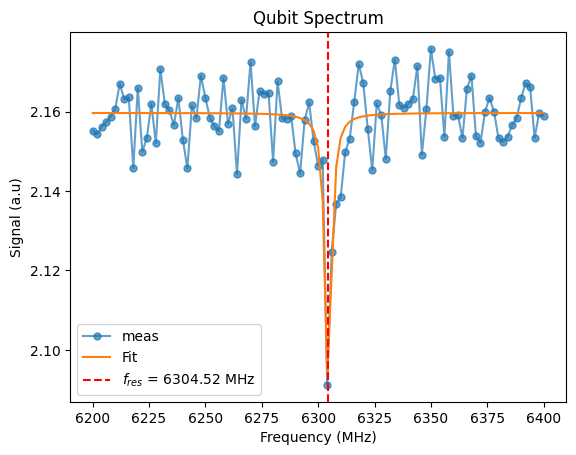

In [289]:
class Cooling_ef(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']


        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=cfg['cool1_mixer_freq'])
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )


        ### test reset to 1 ###
   
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)

        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])





expt_cfg = {
    ## Qubit Params. ##
    'cool1_ch': 7, # channel for cooling pulse
    'cool1_gain': 0.3, # gain for cooling pulse
    'f_cool1': QickSweep1D('freqloop', 6200, 6400), # [MHz]
    'cool1_mixer_freq': 6300,
    'steps': 101,
    'twopulse': False,
    'probe_len':5
     }

run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5
run_cfg['f_res'] = 7447
pyavg = 50
qspec=Cooling_ef(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs1 = qspec.get_pulse_param('cool1', "freq", as_array=True)
spectrum_analyze(freqs1, iq_list[0][0].dot([1,1j]))

  0%|          | 0/50 [00:00<?, ?it/s]

221.6

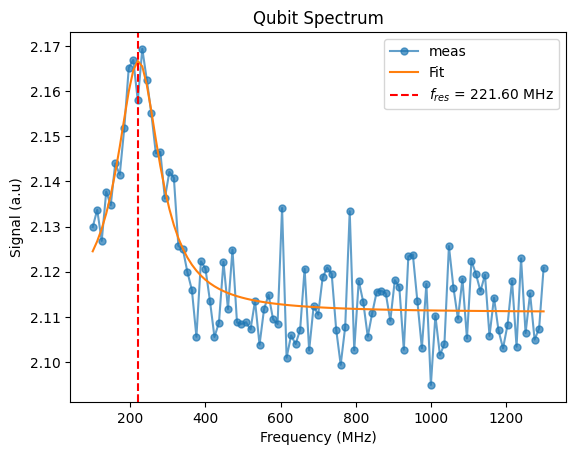

In [305]:
class Cooling_f0g1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=2, mixer_freq=cfg['cool1_mixer_freq'])
        else:
            self.declare_gen(ch=cool1_ch, nqz=2)

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=2, mixer_freq=cfg['cool2_mixer_freq'])
        else:
            self.declare_gen(ch=cool2_ch, nqz=2)
            
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )


        ### test reset to 1 ###
   
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)

        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)

        # self.delay_auto(0.05)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])



config['res_gain'] = 0.2
expt_cfg = {
    ## Qubit Params. ##
    'cool1_ch': 7, # channel for cooling pulse
    'cool1_gain': 0.1, # gain for cooling pulse
    'cool2_ch': 5, # channel for second cooling pulse
    'cool2_gain': 0.1, # gain for second cooling pulse

    'f_cool1': 6304, # [MHz]
    'f_cool2': QickSweep1D('freqloop', 100, 1300), # [MHz]
    'cool1_mixer_freq': 6304,
    'cool2_mixer_freq':1200,
    'probe_len':1,
    'steps': 101,
    'twopulse': True,
     }

run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5
run_cfg['f_res'] = 7447
pyavg = 50
qspec=Cooling_f0g1(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs2 = qspec.get_pulse_param('cool2', "freq", as_array=True)
spectrum_analyze(freqs2, iq_list[0][0].dot([1,1j]))

In [311]:
class Cooling_f0g1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=2, mixer_freq=cfg['cool1_mixer_freq'])
        else:
            self.declare_gen(ch=cool1_ch, nqz=2)

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=2, mixer_freq=cfg['cool2_mixer_freq'])
        else:
            self.declare_gen(ch=cool2_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("gainloop", cfg["stepsg"])
        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )


        ### test reset to 1 ###
   
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)

        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])



config['res_gain'] = 0.2
expt_cfg = {
    ## Qubit Params. ##
    'cool1_ch': 7, # channel for cooling pulse
    'cool1_gain': QickSweep1D('gainloop', 0.1, 0.5), # gain for cooling pulse
    'cool2_ch': 5, # channel for second cooling pulse
    'cool2_gain': 0.5, # gain for second cooling pulse

    'f_cool1': 6304, # [MHz]
    'f_cool2': QickSweep1D('freqloop', 100, 1300), # [MHz]
    'cool1_mixer_freq': 6304,
    'cool2_mixer_freq':1200,
    'probe_len':1,
    'steps': 101,
    'stepsg':21,
    'twopulse': True,
     }

run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5
run_cfg['f_res'] = 7447
pyavg = 50
qspec=Cooling_f0g1(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs2 = qspec.get_pulse_param('cool2', "freq", as_array=True)
gain = qspec.get_pulse_param('cool1', "gain", as_array=True)

  0%|          | 0/50 [00:00<?, ?it/s]

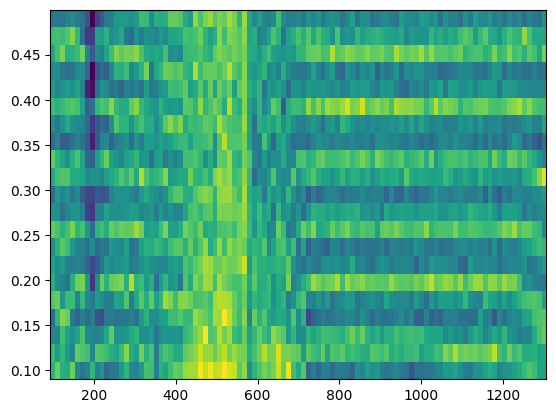

In [312]:
gain = qspec.get_pulse_param('cool1', "gain", as_array=True)
plt.pcolormesh(freqs2, gain, np.abs(iq_list[0][0].dot([1,1j])))

In [313]:
class Cooling(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=2, mixer_freq=cfg['cool1_mixer_freq'])
        else:
            self.declare_gen(ch=cool1_ch, nqz=2)

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=2, mixer_freq=cfg['cool2_mixer_freq'])
        else:
            self.declare_gen(ch=cool2_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop2", cfg["steps2"])
        self.add_loop("freqloop1", cfg["steps1"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )


        ### test reset to 1 ###
   
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)

        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])



config['res_gain'] = 0.2
expt_cfg = {
    ## Qubit Params. ##
    'cool1_ch': 7, # channel for cooling pulse
    'cool1_gain':0.5, # gain for cooling pulse
    'cool2_ch': 5, # channel for second cooling pulse
    'cool2_gain': 0.5, # gain for second cooling pulse

    'f_cool1': QickSweep1D('freqloop1', 6250, 6350), # [MHz]
    'f_cool2': QickSweep1D('freqloop2', 1250, 1352), # [MHz]
    'cool1_mixer_freq': 6304,
    'cool2_mixer_freq':1200,
    'probe_len':1,
    'steps1': 31,
    'steps2':31,
    'twopulse': True,
     }

run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5
run_cfg['f_res'] = 7447
pyavg = 50
qspec=Cooling(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs1 = qspec.get_pulse_param('cool1', "freq", as_array=True)
freqs2 = qspec.get_pulse_param('cool2', "freq", as_array=True)


  0%|          | 0/50 [00:00<?, ?it/s]

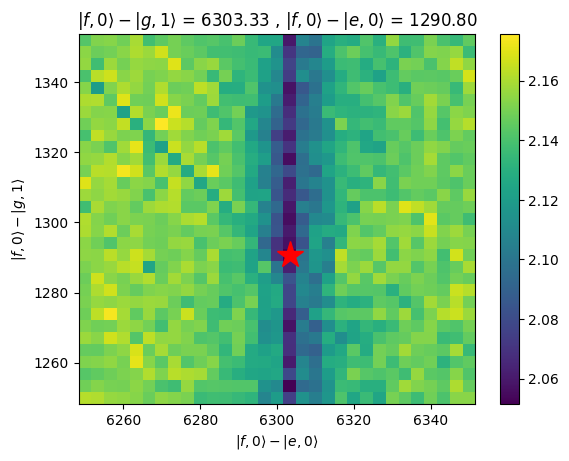

In [314]:
cooling_list = iq_list[0][0].dot([1,1j])
avg_abs, avg_angle = np.abs(cooling_list), np.angle(cooling_list)
plt.pcolormesh(freqs1, freqs2, avg_abs)

plt.ylabel(r'$|f,0\rangle - |g,1\rangle$')
plt.xlabel(r'$|f,0\rangle - |e,0\rangle$')
plt.colorbar()
max_idx = np.unravel_index(np.argmax((avg_abs-np.mean(avg_abs))**2), avg_abs.shape)
idx1, idx2 = max_idx
max1 = freqs1[idx2]
max2 = freqs2[idx1]
plt.plot(max1, max2, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.title(rf'$|f,0\rangle - |g,1\rangle$ = {max1:.2f} , $|f,0\rangle - |e,0\rangle$ = {max2:.2f}')

config['f_cool1'] = round(max1,2)
config['f_cool2'] = round(max2,2)


In [324]:
def auto_unit(value, base_unit=""):
    prefixes = {
        -12: "p",   # pico
        -9:  "n",   # nano
        -6:  "u",   # micro
        -3:  "m",   # milli
         0:  "",    # base
         3:  "k",   # kilo
         6:  "M",   # mega
         9:  "G",   # giga
    }
    
    if value == 0:
        return {"unit": base_unit, "value": 0}

    import math
    exp = int(math.floor(math.log10(abs(value)) / 3) * 3)
    exp = max(min(exp, 9), -12)  # 限制在 pico ~ G

    scaled_value = value / (10**exp)
    prefix = prefixes[exp]

    return {"unit": f"{prefix}{base_unit}", "value": scaled_value}


In [323]:
mode = "current"
yoko_value = 0.000856

value = auto_unit(yoko_value, "A" if mode == "current" else "V")
label = f"{'Current' if mode == 'current' else 'Voltage'} ({value['unit']})"

print(value)  # {'unit': 'mA', 'value': 0.856}
# print(label)  # Current (mA)


{'unit': 'uA', 'value': 856.0}


In [225]:
config['f_cool1'], config['f_cool2']

(4688.97, 2634.48)

# cooling res

In [219]:
class Coolingres(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=4600)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=2600)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_pulse(ch=cool1_ch, name="cool1",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_pulse(ch=cool2_ch, name="cool2",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.5)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])



run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5
pyavg = 10



  0%|          | 0/10 [00:00<?, ?it/s]

{'Fres(GHz)': 7447041524.164,
 'Qi': 41940,
 'Ql': 3659,
 'absQc': 4009,
 'κ(MHz)': 2.04}


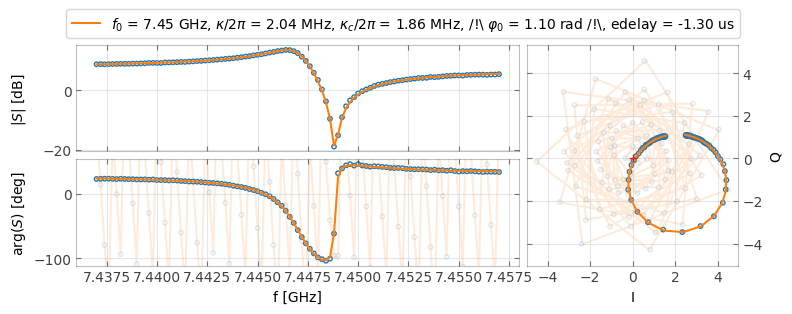

In [220]:

center = r[qubit_idx]
START_FREQ = center - 10 # [MHz]
STOP_FREQ =  center + 10 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.2
}
run_cfg = {**config, **exp_cfg}

pyavg = 10

prog = Coolingres(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
res_onetone = (iq_list[0][0].dot([1,1j]))

fit = resonator_circlefit(freqs, res_onetone)
f_res = round(fit[0]/1e6, 3)
config['f_res'] = f_res

In [56]:
data_path = data_path
exp_name = f"R{qubit_idx+1} resonator cooling spec"


file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  res_onetone},
        comment=(f'f_res = {f_res:.3f} MHz\
                 \nYoko = {yoko_connect} mA'),
        tag= 'OneTone'
)

NameError: name 'data_path' is not defined

# cooling chi

In [69]:
class Coolingchi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=2500)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=2500)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_pulse(ch=cool1_ch, name="cool1",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_pulse(ch=cool2_ch, name="cool2",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                           style="flat_top",
                           envelope="ramp",
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'],
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse_pi", t=0)
        self.delay_auto(0.5)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])





In [70]:

center = r[qubit_idx]
START_FREQ = center - 10 # [MHz]
STOP_FREQ =  center + 10 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.2
}
run_cfg = {**config, **exp_cfg}

pyavg = 20

prog = Coolingchi(soccfg, reps=100, final_delay=1, cfg=run_cfg)
e = prog.acquire(soc, soft_avgs=pyavg, progress=True)
run_cfg['pi_gain'] = 0
prog = Coolingchi(soccfg, reps=100, final_delay=1, cfg=run_cfg)
g = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)


  0%|          | 0/10100 [00:00<?, ?it/s]

  0%|          | 0/10100 [00:00<?, ?it/s]

-0.5999874114995691


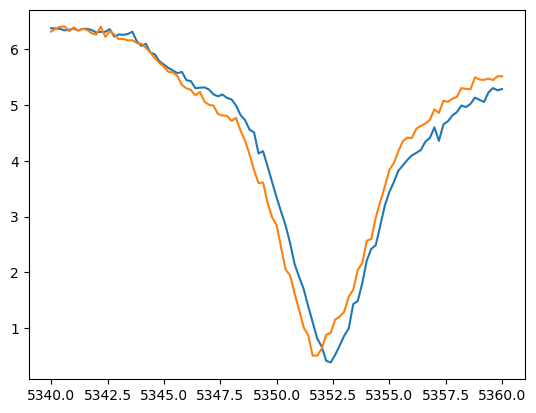

In [77]:
plt.plot(freqs, np.abs(e[0][0].dot([1,1j])), label='Excited state')
plt.plot(freqs, np.abs(g[0][0].dot([1,1j])), label='ground state')
fe = freqs[np.argmin(np.abs(e[0][0].dot([1,1j])))]
fg = freqs[np.argmin(np.abs(g[0][0].dot([1,1j])))]
print(fg - fe)

# cooling spec

  0%|          | 0/10 [00:00<?, ?it/s]

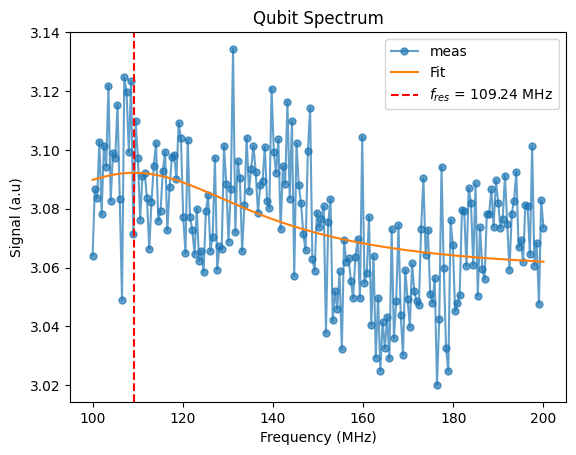

In [222]:
class Cooling2(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=4000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=2600)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        self.add_gauss(ch=res_ch, name="readout", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="qubit_flat", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       envelope="qubit_flat",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])




cemter = 150

START_FREQ = cemter - 50# [MHz]
STOP_FREQ = cemter + 50  # [MHz]
STEPS = 200
config.update({'qmixer_freq':cemter, 'qubit_gain':0.5, 'qubit_ch':11, 'res_gain':0.3, 'nqz':1})

expt_cfg = {
    ## Qubt Params. ##
    'steps': STEPS, # Number of sweep points
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
     }


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5

pyavg = 10
qspec=Cooling2(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)

f_q = spectrum_analyze(freqs, np.abs(iq_list[0][0].dot([1,1j])))
config['f_ge'] = round(f_q, 3)
config['qmixer_freq']= round(f_q,3)

In [21]:
class Acstark(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=2500)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=2500)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("gainloop", cfg["steps_g"])
        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)


        self.add_gauss(ch=res_ch, name="readout", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_pulse(ch=res_ch, name="res_pump_pulse",
                       style="flat_top",
                       envelope="readout",
                       length=cfg['probe_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_pump_gain'],
                      )
        ## cooling ##
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="qubit_flat", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       envelope="qubit_flat",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.5)
        self.pulse(ch=cfg["res_ch"], name="res_pump_pulse", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])




cemter = 350

START_FREQ = cemter - 100# [MHz]
STOP_FREQ = cemter + 100  # [MHz]
STEPS = 100
config.update({'qmixer_freq':cemter, 'qubit_gain':0.1, 'qubit_ch':11, 'res_gain':0.4, 'nqz':1})

expt_cfg = {

    ## Qubit Params. ##
    'steps': STEPS, # Number of sweep points
    'steps_g': 50, # Number of gain sweep points
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_pump_gain':  QickSweep1D('gainloop', 0, 0.5),
     }


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5

pyavg = 20
qspec=Acstark(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)
gains = qspec.get_pulse_param('res_pump_pulse', "gain", as_array=True)


  0%|          | 0/20 [00:00<?, ?it/s]

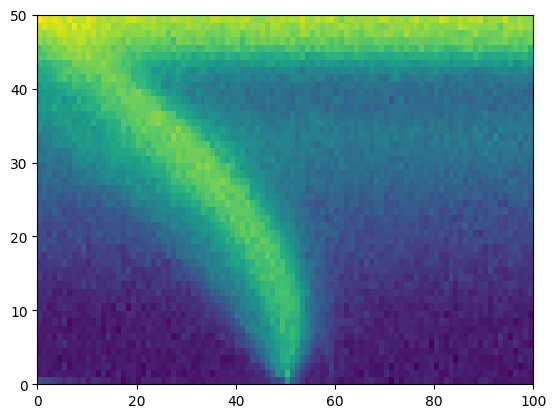

In [22]:
plt.pcolor(np.abs(iq_list[0][0].dot([1,1j])))
# iq_list

# cooling rabi

  0%|          | 0/10 [00:00<?, ?it/s]

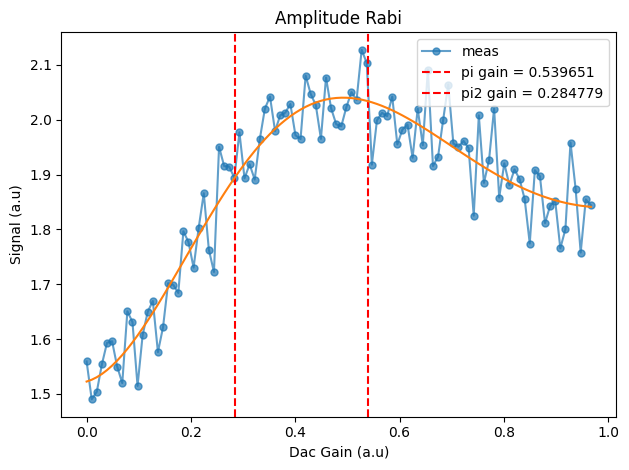

In [ ]:
class Coolingrabi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("gainloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        
        if self.cfg['rabi_protocal'] == 'pi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        elif self.cfg['rabi_protocal'] == 'pipi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
            self.delay_auto(0.0)
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])



STEPS = 100
config.update({'relax_delay':1, 'qb_pulse_style':'flat_top', 'sigma':0.03, 'flat_top_len':0.5, 'nqz':1})

expt_cfg = {
    ## Cooling Params. ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', 0, 1), # [DAC units]
    'rabi_protocal': 'pi',
     }


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5

pyavg = 10
run_cfg['rabi_protocal']='pi'
amp_rabi=Coolingrabi(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], config['pi2_gain'] = amprabi_analyze(gains, (iq_list[0][0].dot([1,1j])), protocal=None)

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} cooling power rabi"

try:
        run_cfg.pop('qubit_gain')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'relax={run_cfg["relax_delay"]}, at {Yoko_current}mA\
                \n\n{run_cfg}',
        tag='Cooling')

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

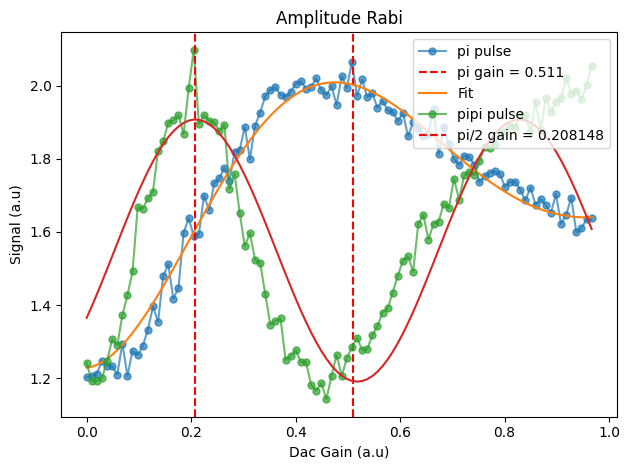

In [29]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 100


config.update({'relax_delay':1, 'qb_pulse_style':'flat_top', 'sigma':0.01, 'flat_top_len':1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain":QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
     }
run_cfg = {**config, **expt_cfg}
pyavg = 10
run_cfg = {**config, **expt_cfg}

run_cfg['rabi_protocal']='pi'
amp_rabi=Coolingrabi(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, rounds=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])),protocal=run_cfg['rabi_protocal'], fit=True)

run_cfg['rabi_protocal']='pipi'
amp_rabi=Coolingrabi(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, rounds=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi2 = iq_list[0][0].dot([1,1j])
config['pi2_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])),protocal=run_cfg['rabi_protocal'])

In [25]:
config['pi_gain'] = 2*config['pi2_gain']

In [27]:
data_path = data_path
exp_name = f"q{qubit_idx+1} power rabi fine tune"
Yoko_current=None
try:
    run_cfg.pop('qubit_gain')
except:
    pass
dict_val = yml_comment(run_cfg)
file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        y_info={'name': '# pi pulse ', 'unit': "#",
                'values': [1,2]},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array([power_rabi, power_rabi2])},
        comment=f'relax={run_cfg["relax_delay"]}, at {Yoko_current}mA\
                \n\n{dict_val}',
        tag='Rabi')

# cooling ramsey

  0%|          | 0/20 [00:00<?, ?it/s]

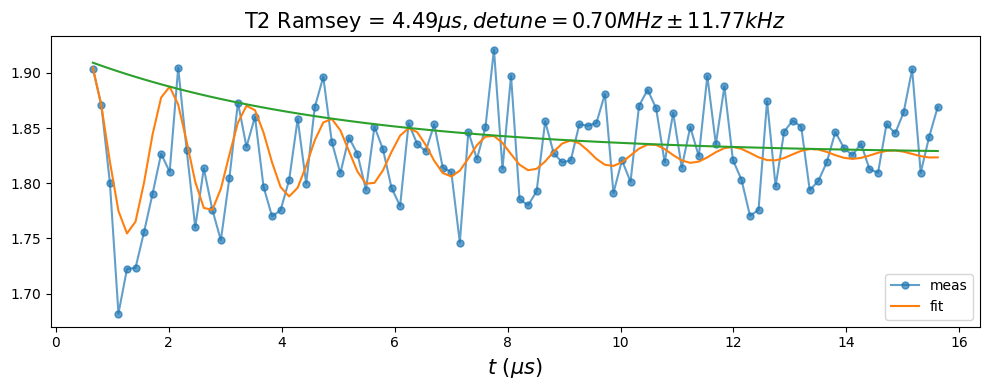

In [91]:
class Coolingramsey(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("waitloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )


        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )

            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp", 
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp",
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)

        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)
        self.delay_auto(cfg['wait_time'], tag='wait')
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)

        self.delay_auto(t=0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


START_TIME = 0. # [us]
STOP_TIME = 15 # [us]
STEPS = 100

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'ramsey_freq':0.5,
    }


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5

pyavg = 20

ramsey=Coolingramsey(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = ramsey.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times_t2 = ramsey.get_time_param('wait', "t", as_array=True)
ramsey = iq_list[0][0].dot([1,1j])

t2r = T2fring_analyze(delay_times_t2, (ramsey), prefix='Ramsey')

In [92]:
activate_correct=True
if activate_correct:
    if abs(t2r[1]-run_cfg['ramsey_freq'])>0.001:
        config['f_ge'] = config['f_ge']-round((t2r[1]-run_cfg['ramsey_freq']),5)
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),5)}')
        print('Correct')
    else:
        print(f' detune < 1kHz')

over detune 0.20174
Correct


In [41]:
data_path = data_path
exp_name = f"q{qubit_idx+1} cooling T2 Ramsey "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times_t2*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'Detune = {t2r[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2R = {t2r[3]:.2f}us\
                \nYokogawa = {Yoko_current}mA\
                \n\n{dict_val}'),
        tag='Cooling')

# Cooling Echo

  0%|          | 0/20 [00:00<?, ?it/s]

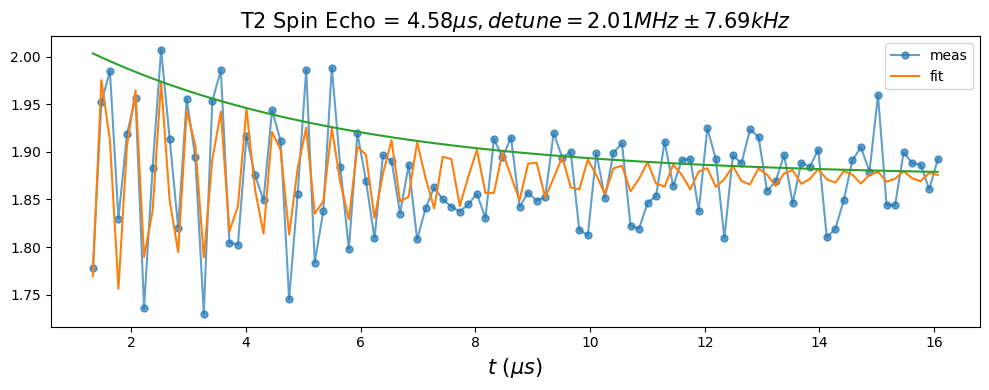

In [96]:
class CoolingEcho(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("waitloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase']+ cfg['wait_time']*360*cfg['ramsey_freq'], 
                        gain=cfg['pi2_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                           style="flat_top",
                           envelope="ramp",
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'],
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                           style="flat_top",
                           envelope="ramp",
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'],
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi2_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",
                           style="flat_top",
                           envelope="ramp",
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'],
                           phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                           gain=cfg['pi2_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # Cooling process
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        # Qubit drive
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse1", t=0)  #play pulse
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait1') # wait_time after last pulse (wait / 2)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse_pi", t=0)  #play pulse
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait2') # wait_time after last pulse (wait / 2)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  #play pulse

        self.delay_auto(t=0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


START_TIME = 0.0 # [us]
STOP_TIME = 15# [us]
STEPS = 100
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'ramsey_freq':2,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'relax_delay':1
    }


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5

pyavg = 20

spinecho=CoolingEcho(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = spinecho.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
spinecho = iq_list[0][0].dot([1,1j])

t2e = T2fring_analyze(delay_times1+delay_times2, spinecho,  prefix='Spin Echo', ramsey_freq=run_cfg['ramsey_freq'])

In [47]:
data_path = data_path
exp_name = f"q{qubit_idx+1} cooling T2 Echo "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': (delay_times1+delay_times2)*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  spinecho},
        comment=(f'Detune = {t2e[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2R = {t2e[3]:.2f}us\
                \nYokogawa = {0}mA\
                \n\n{dict_val}'),
        tag='Cooling')

# Cooling T1

  0%|          | 0/20 [00:00<?, ?it/s]

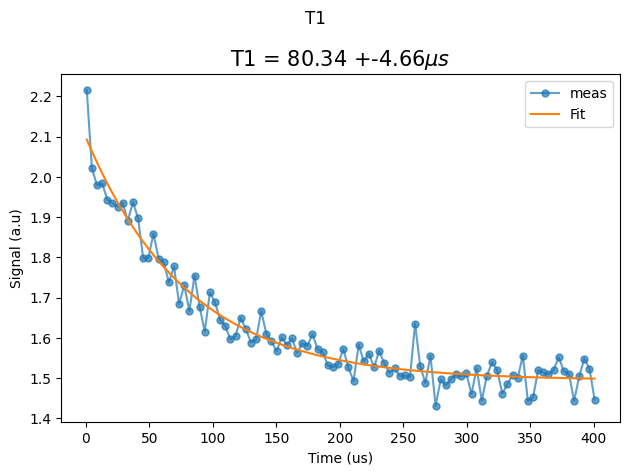

In [97]:
class CoolingT1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("waitloop", cfg["steps"])

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                           style="flat_top",
                           envelope="ramp",
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'],
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # Cooling process
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)

        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse_pi", t=0)
        self.delay_auto(cfg['wait_time']+0.05, tag='wait')

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


START_TIME = 0.0 # [us]
STOP_TIME = 400 # [us]
STEPS = 100
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'relax_delay':1
    }


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5

pyavg = 20

T1=CoolingT1(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = T1.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times = T1.get_time_param('wait', "t", as_array=True)

t1 = T1_analyze(delay_times, (iq_list[0][0].dot([1,1j])))

In [52]:
data_path = data_path
exp_name = f"q{qubit_idx+1} cooling T1"

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'T1 = {t1[3]:.2f}us\
                \nYokogawa = {Yoko_current}mA\
                \n\n{dict_val}'),
        tag='Cooling')

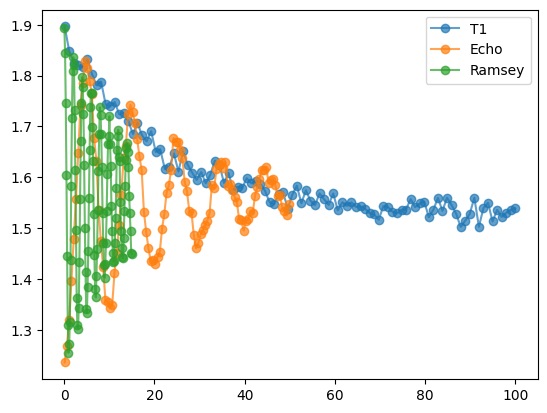

In [53]:
plt.plot(delay_times, np.abs(iq_list[0][0].dot([1,1j])), marker='o', label='T1', alpha=0.7)
plt.plot(delay_times1+delay_times2, np.abs(spinecho), marker='o', label='Echo', alpha=0.7)
plt.plot(delay_times_t2, np.abs(ramsey), marker='o', label='Ramsey', alpha=0.7)
plt.legend()

# Cooling shot

In [98]:
# Separate g and e per each experiment defined.

class SingleShotProgram_g(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots

        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # Cooling process
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.5)
        # no qubit pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


class SingleShotProgram_e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots
        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )
        if cfg['qb_pulse_style']=='arb':
            self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase'],
                        gain= cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="flat_top", 
                        envelope="ramp", 
                        length=cfg['flat_top_len'], 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # Cooling process
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.5)

        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(0.02, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [108]:
run_cfg['probe_len'] = 100

In [105]:
SHOTS = 10000


run_cfg = {**config, **expt_cfg}
# run_cfg['ro_len'] = 4
# run_cfg['f_res']=5791.078 
# run_cfg['res_gain'] = 0.7
run_cfg['steps'] = SHOTS

ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_g = ssp_g.acquire(soc, rounds=1, progress=True)

ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_e = ssp_e.acquire(soc, rounds=1, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

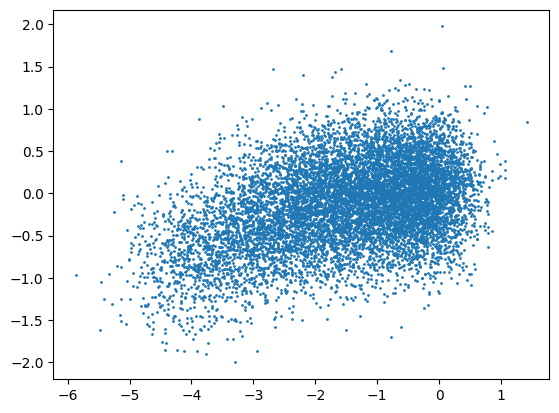

In [107]:
plt.plot(I_g, Q_g, 'o', markersize=1, label='g state')

g unrotated averages:
I -1.4703281901041665 +/- 1.2537860602476865 	 Q -0.12746318359375 +/- 0.4950237588847387 	 Amp 1.6286745938229632 +/- 1.158688449909744
Rotated (theta=2.9793160734134156):
I 1.471604681389959 +/- 1.2718417212930355 	 Q -0.1117654306930608 +/- 0.446594494715463 	 Amp 1.4758427591674015 +/- 1.158688449909744
e unrotated averages:
I -1.8110607096354168 +/- 1.3055298086488165 	 Q -0.18324661458333336 +/- 0.5017203515383843 	 Amp 1.941457147069936 +/- 1.2249064267326186
Rotated (theta=2.9793160734134156):
I 1.8168733319203587 +/- 1.3253934117784933 	 Q -0.1117654306930608 +/- 0.4466135873801647 	 Amp 1.8203077255621896 +/- 1.2249064267326186
Attempted to init fitparam 4 to 0.9335561446273073, which is out of bounds 2.186571099120164 to 5.908212531121335. Instead init to 4.04739181512075
Attempted to init fitparam 4 to 0.9335561446273073, which is out of bounds 2.186571099120164 to 5.908212531121335. Instead init to 4.04739181512075


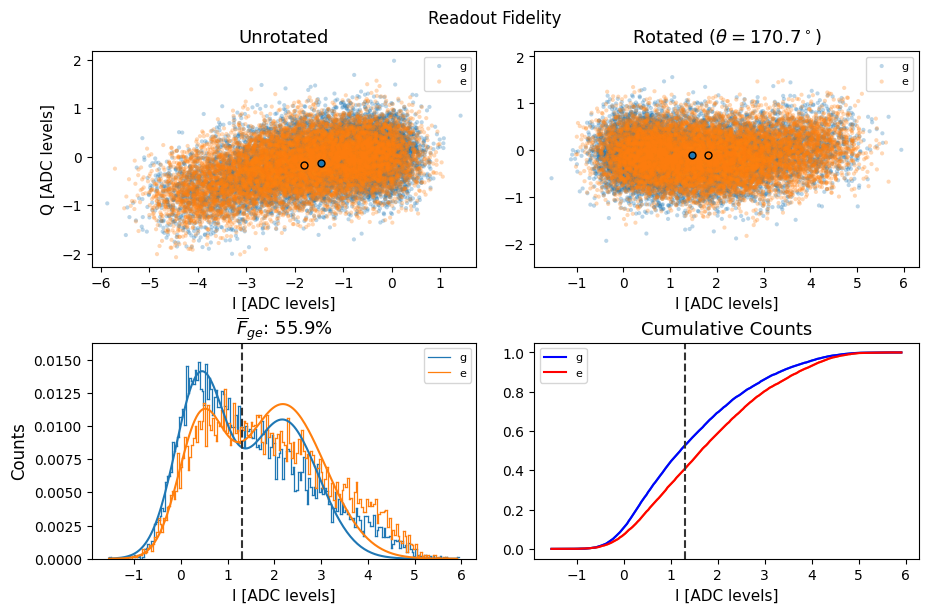

fidelity:[0.5594] 
thressholds:[1.3075904594012941] 
theta:170.70223684207724
Unrotated:
Ig -1.2530924479166667 +/- 1.2537860602476865 	 Qg -0.10579427083333333 +/- 0.4950237588847387 	 Amp g 1.2575504406452016 +/- 1.158688449909744
Ie -1.6865234375 +/- 1.3055298086488165 	 Qe -0.16438802083333334 +/- 0.5017203515383843 	 Amp e 1.6945160744679635 +/- 1.127585751768617
Rotated:
Ig 1.2289525213010366 +/- 1.2537860602476865 	 Qg -0.1938459618208479 +/- 0.4950237588847387 	 Amp g 1.2441465173067137 +/- 1.158688449909744
Ie 1.6609403584848363 +/- 1.3055298086488165 	 Qe -0.2211700385981098 +/- 0.5017203515383843 	 Amp e 1.6756011042062564 +/- 1.127585751768617
g correctly categorized: 50.31597953656335%
e correctly categorized: 61.42325861895668%


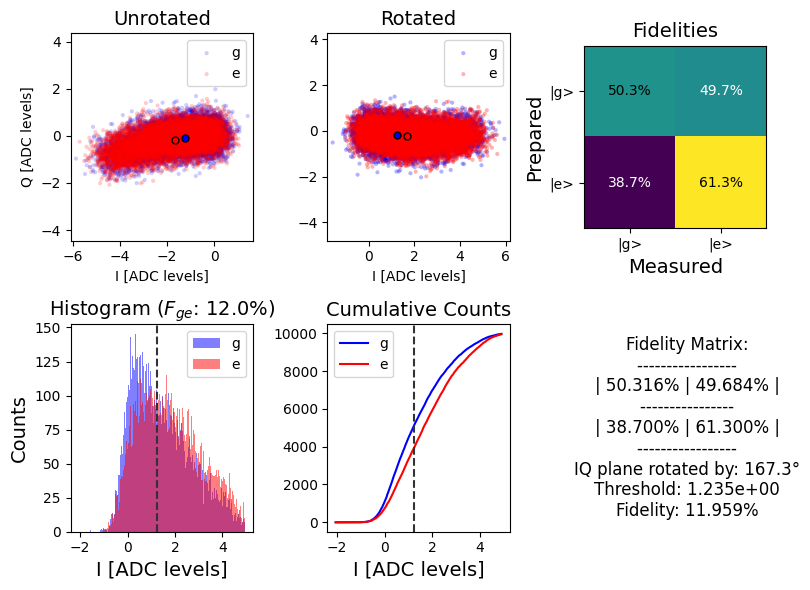

([0.11959032031328447], [1.235088123378572], 167.3010929401783)

In [106]:
I_g = iq_list_g[0][0].T[0]
Q_g = iq_list_g[0][0].T[1]
I_e = iq_list_e[0][0].T[0]
Q_e = iq_list_e[0][0].T[1]


data={
    "Ig":I_g,
    "Qg": Q_g,
    "Ie": I_e,
    "Qe": Q_e
}
f = histplot(data, fid_avg=True, fit=True, gauss_overlap=False)
hist(data, b_plot=True)

## Readout Optimization

## Gain VS Frequency

In [40]:
freq_steps = 20
freq_step_size = 1 # [MHz]
freq_start = (config['f_res']) - ((freq_steps/2)*freq_step_size)
gain_steps = 18
gain_step_size = 0.05 # [DAC units]
gain_start = 0.05
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for gains in tqdm(range(gain_steps), desc='Gain loop', leave=False):
        run_cfg.update({
            ## Sweep Params: ##
            'steps': SHOTS, # Number of shot points (outer loop)
            'f_res': freq_start + freq_step_size*freqs, # [MHz]
            'res_gain': gain_start + gain_step_size*gains, # [DAC units]
            'ro_len':1
            })

        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

...

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_37080\525231264.py:38: UserWarning: The following kwargs were not used by contour: 'interpolation'
  figB = plt.contour(gains_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')


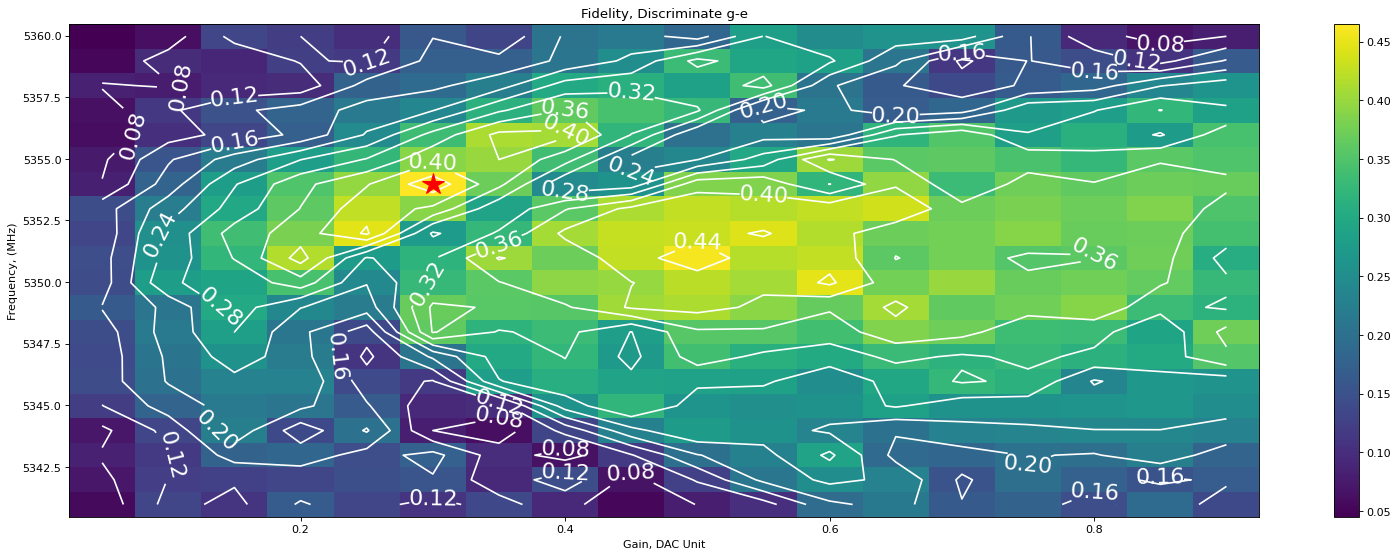

5353.973 0.3


In [42]:
fid_Array =np.zeros([freq_steps,gain_steps])
for index_freq in range(freq_steps):
    for index_amp in range(gain_steps):
        I_g = I_g_array[index_freq][0][index_amp][0]
        Q_g = Q_g_array[index_freq][0][index_amp][0]
        I_e = I_e_array[index_freq][0][index_amp][0]
        Q_e = Q_e_array[index_freq][0][index_amp][0]


        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q) ** 2


        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom

        th_list = np.linspace(min(gstate), max(estate), 1000)
        gstate = gstate.reshape(1, -1)
        estate = estate.reshape(1, -1)
        th_list = th_list.reshape(-1, 1)

        g_cdf = np.sum(gstate < th_list, axis=1) / gstate.shape[1]
        e_cdf = np.sum(estate > th_list, axis=1) / estate.shape[1]
        fidelity = (g_cdf + e_cdf) / 2
        fid_Array[index_freq, index_amp] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
gains_list = np.zeros(gain_steps)
for gain in range(gain_steps):
    gains_list[gain] = gain_start + gain_step_size*gain
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(gains_list,freqs_list,fid_Array)
figB = plt.contour(gains_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"Gain, DAC Unit")
plt.ylabel(r"Frequency, (MHz)")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_gain_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_gain = gains_list[max_gain_idx]
plt.plot(max_gain, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.title(r"Fidelity, Discriminate g-e")
plt.colorbar(figA)
plt.show()
print(max_freq, max_gain)
run_cfg['f_res'] = round(max_freq,5)
run_cfg['res_gain'] = round(max_gain,5)
#plt.savefig("FidwithoutJPA.png",dpi=300,bbox_inches='tight')

### Length VS Frequency

In [43]:
freq_steps = 20
freq_step_size = 1 # [MHz]
freq_start = (config['f_res']) - ((freq_steps/2)*freq_step_size)
length_steps = 20
length_step_size = 0.2 # [us units]
length_start = 0.5
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for lengths in tqdm(range(length_steps), desc='ro len loop', leave=False):
        run_cfg.update({'steps': SHOTS,
                        'f_res': freq_start + freq_step_size*freqs,
                        'ro_len': length_start + length_step_size*lengths,
                        'res_gain':0.7
                        })


        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

...

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_37080\669718863.py:38: UserWarning: The following kwargs were not used by contour: 'interpolation'
  figB = plt.contour(lengths_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')


5351.973 2.5


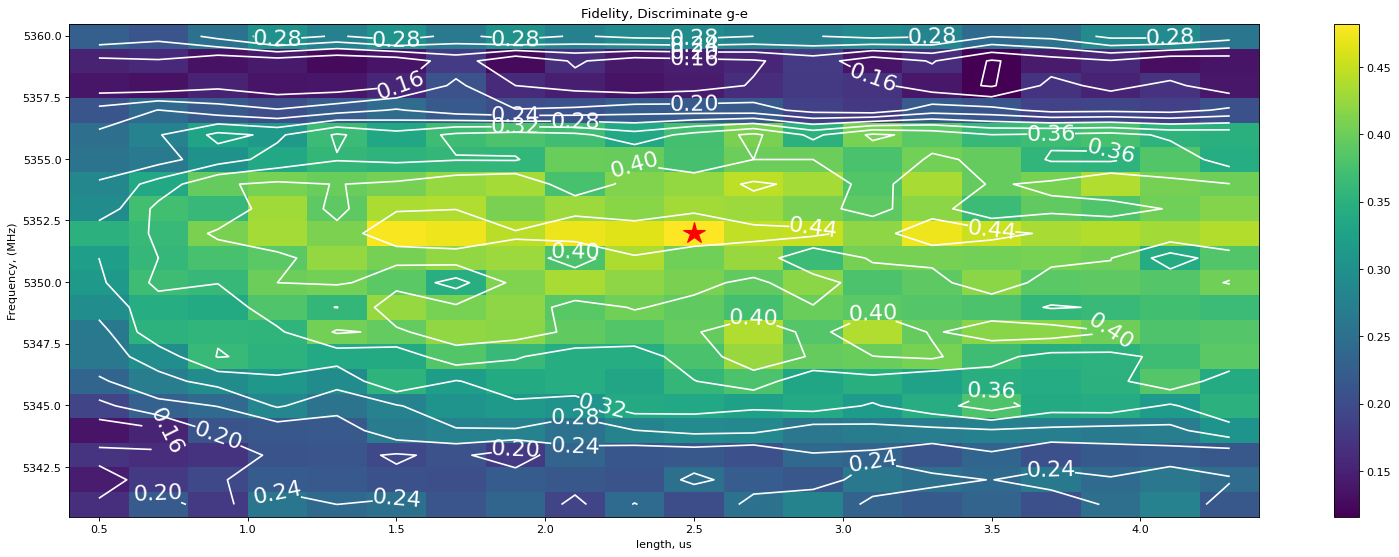

In [44]:
fid_Array = np.zeros((freq_steps, length_steps))

for index_freq in range(freq_steps):
    for index_length in range(length_steps):
        I_g = I_g_array[index_freq][0][index_length][0]
        Q_g = Q_g_array[index_freq][0][index_length][0]
        I_e = I_e_array[index_freq][0][index_length][0]
        Q_e = Q_e_array[index_freq][0][index_length][0]

        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q)**2

        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom


        th_list = np.linspace(np.min(gstate), np.max(estate), 1000).reshape(-1, 1)
        g_proj = np.array(gstate).reshape(1, -1)
        e_proj = np.array(estate).reshape(1, -1)

        g_cdf = np.sum(g_proj < th_list, axis=1) / g_proj.shape[1]
        e_cdf = np.sum(e_proj > th_list, axis=1) / e_proj.shape[1]
        fidelity = (g_cdf + e_cdf) / 2

        fid_Array[index_freq, index_length] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
lengths_list = np.zeros(length_steps)
for length in range(length_steps):
    lengths_list[length] = length_start + length_step_size*length
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(lengths_list,freqs_list,fid_Array)
figB = plt.contour(lengths_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"length, us")
plt.ylabel(r"Frequency, (MHz)")
plt.title(r"Fidelity, Discriminate g-e")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_length_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_length = lengths_list[max_length_idx]
plt.plot(max_length, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.colorbar(figA)

print(max_freq, max_length)
run_cfg['f_res'] = round(max_freq, 5)
run_cfg['ro_len'] = round(max_length, 2)

# Cooling All XY

In [52]:
class AllXY(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=2000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # Cooling process
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.05)
        if cfg['allxy_gates'][0]=='I':
            pass
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][0]}", t=0) 
        self.delay_auto(0.01) 
        if cfg['allxy_gates'][1]=='I':
            pass
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][1]}", t=0) 

        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [53]:
sequence = [
    ("I", "I"),
    ("x180", "x180"),
    ("y180", "y180"),
    ("x180", "y180"),
    ("y180", "x180"),
    ("x90", "I"),
    ("y90", "I"),
    ("x90", "y90"),
    ("y90", "x90"),
    ("x90", "y180"),
    ("y90", "x180"),
    ("x180", "y90"),
    ("y180", "x90"),
    ("x90", "x180"),
    ("x180", "x90"),
    ("y90", "y180"),
    ("y180", "y90"),
    ("x180", "I"),
    ("y180", "I"),
    ("x90", "x90"),
    ("y90", "y90"),
]


  0%|          | 0/21 [00:00<?, ?it/s]

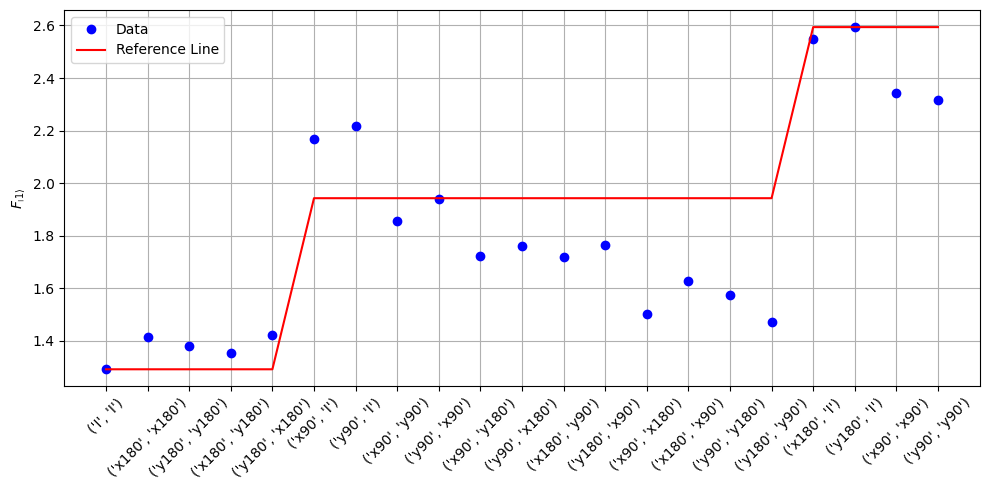

In [54]:


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 5
run_cfg['ro_len'] = 5
pyavg = 10

allxy_lst=[]
for gate in tqdm(sequence):
    run_cfg['allxy_gates'] = gate
    allxy=AllXY(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = allxy.acquire(soc, rounds=pyavg, progress=False, threshold=run_cfg['thresholds'])
    allxy_lst.append(iq_list[0][0].dot([1,1j]))

amp = np.abs(allxy_lst)
plt.figure(figsize=(10, 5))
plt.plot(amp, 'bo', label='Data')
plt.plot([np.min(amp)]*5 + [0.5*(np.max(amp) + np.min(amp))]*12 + [np.max(amp)]*4, 'r-', label='Reference Line')
plt.xticks(np.arange(len(sequence)), sequence, rotation=45)
plt.ylabel(r'$F_{\left|1\right\rangle}$')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

In [63]:
run_cfg.pop('wait_time')

In [64]:
data_path = data_path
exp_name = f"q{qubit_idx+1} cooling AllXY"

ref = [np.min(amp)]*5 + [np.mean(amp)]*12 + [np.max(amp)]*4


dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': range(len(sequence))},
        y_info={'name': '#', 'unit': "#",
                'values': [0,1]},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array([allxy_lst, ref])},
        comment=(f'T1 = {t1[3]:.2f}us\
                \nYokogawa = {Yoko_current}mA\
                \n\n{dict_val}'),
        tag='Cooling')

# RB

In [ ]:
class RB(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=3000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=2000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
            
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="readout", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="readout",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=cool1_ch, name="cooling1", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool1_ch, name="cool1",
                       envelope="cooling1",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_gauss(ch=cool2_ch, name="cooling2", sigma=0.005, length=0.005*5, even_length=True)
        self.add_pulse(ch=cool2_ch, name="cool2",
                       envelope="cooling2",
                       style="flat_top", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            ## X pulse ##
            self.add_pulse(ch=qubit_ch, name="X", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="-X", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="X/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="-X/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=-cfg['pi2_gain'], 
                    )
            ## Y pulse ##
            self.add_pulse(ch=qubit_ch, name="Y", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="-Y", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="Y/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="-Y/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=-cfg['pi2_gain'], 
                    )
            
        # elif cfg['qb_pulse_style']=='flat_top':
        #      ## X pulse ##
        #     self.add_pulse(ch=qubit_ch, name="x180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=0,
        #                 gain=cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="-x180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=0,
        #                 gain=-cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="x90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=0,
        #             gain=cfg['pi2_gain'], 
        #             length = cfg['flat_top_len'],
        #             )
        #     self.add_pulse(ch=qubit_ch, name="-x90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=0,
        #             gain=-cfg['pi2_gain'], 
        #             length = cfg['flat_top_len'],
        #             )
        #     ## Y pulse ##
        #     self.add_pulse(ch=qubit_ch, name="y180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=-90,
        #                 gain=cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="-y180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=-90,
        #                 gain=-cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="y90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=-90,
        #             gain=cfg['pi2_gain'],
        #             length = cfg['flat_top_len'], 
        #             )
        #     self.add_pulse(ch=qubit_ch, name="-y90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=-90,
        #             gain=-cfg['pi2_gain'],
        #             length = cfg['flat_top_len'], 
        #             )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # Cooling process
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.5)
        for i in self.cfg['gate_seq']:
            if i=='I' or i=='-I':
                self.delay_auto(cfg['sigma']*5)
                
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name=f"{i}", t=0) 
                self.delay_auto(0.0)

        self.delay_auto(0.01) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [78]:
import numpy as np

"""
Define matrices representing (all) Clifford gates for single
qubit in the basis of Z, X, Y, -Z, -X, -Y, indicating
where on the 6 cardinal points of the Bloch sphere the
+Z, +X, +Y axes go after each gate. Each Clifford gate
can be uniquely identified just by checking where +X and +Y
go.
"""
clifford_1q = dict()
# clifford_1q["Z"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 0, 0, 1, 0, 0],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#     ]
# )
clifford_1q["X"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
    ]
)
clifford_1q["Y"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#     ]
# )
clifford_1q["X/2"] = np.matrix(
    [
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
    ]
)
clifford_1q["Y/2"] = np.matrix(
    [
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["-Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#     ]
# )
clifford_1q["-X/2"] = np.matrix(
    [
        [0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0],
    ]
)
clifford_1q["-Y/2"] = np.matrix(
    [
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
identity = np.diag([1] * 6)
clifford_1q["I"] = identity


# Read pulse as a matrix product acting on state (meaning apply pulses in reverse order of the tuple)
# two_step_pulses = [
#     ("X", "Z/2"),
#     ("X/2", "Z/2"),
#     ("-X/2", "Z/2"),
#     ("Y", "Z/2"),
#     ("Y/2", "Z/2"),
#     ("-Y/2", "Z/2"),
#     ("X", "Z"),
#     ("X/2", "Z"),
#     ("-X/2", "Z"),
#     ("Y", "Z"),
#     ("Y/2", "Z"),
#     ("-Y/2", "Z"),
#     ("X", "-Z/2"),
#     ("X/2", "-Z/2"),
#     ("-X/2", "-Z/2"),
#     ("Y", "-Z/2"),
#     ("Y/2", "-Z/2"),
#     ("-Y/2", "-Z/2"),
# ]

step_pulses = [
    ("Y/2", "X"),
    ("Y/2", "X/2"),
    ("X/2", "-Y/2", "-X/2"),
    ("-X/2", "-Y/2"),
    ("Y/2", "-X/2"),
    ("-X/2", "Y/2", "-X/2"),
    ("X/2", "Y/2"),
    ("-Y/2", "X"),
    ("-X/2", "Y"),
    ("-Y/2", "-X/2"),
    ("X/2", "Y/2", "X/2"),
    ("-X/2", "Y/2"),
    ("X", "Y"),
    ("X/2", "Y"),
    ("-Y/2", "X/2"),
    ("X/2", "Y/2", "-X/2"),
    ("X/2", "-Y/2"),
]

for pulse in step_pulses:
    new_mat = clifford_1q[pulse[0]]
    for p in pulse[1:]:
        new_mat = new_mat @ clifford_1q[p]
    repeat = False
    # Make sure there are no repeats
    for existing_pulse_name, existing_pulse in clifford_1q.items():
        if np.array_equal(new_mat, existing_pulse):
            print("found repeat", pulse, existing_pulse_name)
            repeat = True
    if not repeat:
        clifford_1q[pulse[0] + "," + ",".join(pulse[1:])] = new_mat
clifford_1q_names = list(clifford_1q.keys())
assert (
    len(clifford_1q_names) == 24
), f"you have {len(clifford_1q_names)} elements in your Clifford group instead of 24!"
# print(len(clifford_1q_names), "elements in clifford_1q")
# print(clifford_1q_names)

# Get the average number of X/2 gates per Clifford gate
count = 0
for n in range(len(clifford_1q_names)):  # n is index in clifford_1q_names
    gates = clifford_1q_names[n].split(",")
    for gate in gates:
        # print(gate)
        if gate == "I" or "Z" in gate:
            continue
        if "/2" in gate:
            count += 1
            # print("added 1 to count")
        else:
            count += 2
            # print("added 2 to count")
# print("Average number of X/2 gates per Clifford gate:", count / len(clifford_1q_names))

for name, matrix in clifford_1q.items():
    z_new = np.argmax(matrix[:, 0])  # +Z goes to row where col 0 is 1
    x_new = np.argmax(matrix[:, 1])  # +X goes to row where col 1 is 1
    # print(name, z_new, x_new)
    clifford_1q[name] = (matrix, (z_new, x_new))


def gate_sequence(rb_depth, pulse_n_seq=None, debug=False):
    """
    Generate RB forward gate sequence of length rb_depth as a list of pulse names;
    also return the Clifford gate that is equivalent to the total pulse sequence.
    The effective inverse is pi phase + the total Clifford.
    Optionally, provide pulse_n_seq which is a list of the indices of the Clifford
    gates to apply in the sequence.
    """
    if pulse_n_seq is None:
        pulse_n_seq = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_name_seq = [clifford_1q_names[n] for n in pulse_n_seq]
    if debug:
        print("pulse seq", pulse_name_seq)
    psi_nz = np.matrix([[1, 0, 0, 0, 0, 0]]).transpose()
    psi_nx = np.matrix([[0, 1, 0, 0, 0, 0]]).transpose()
    for n in pulse_n_seq:  # n is index in clifford_1q_names
        gates = clifford_1q_names[n].split(",")
        for gate in reversed(gates):  # Apply matrices from right to left of gates
            psi_nz = clifford_1q[gate][0] @ psi_nz
            psi_nx = clifford_1q[gate][0] @ psi_nx
    psi_nz = psi_nz.flatten()
    psi_nx = psi_nx.flatten()
    if debug:
        print("+Z axis after seq:", psi_nz, "+X axis after seq:", psi_nx)

    total_clifford = None
    if np.argmax(psi_nz) == 0:
        total_clifford = "I"
    else:
        for clifford in clifford_1q_names:  # Get the clifford equivalent to the total seq
            if clifford_1q[clifford][1] == (np.argmax(psi_nz), np.argmax(psi_nx)):
                # z_new, x_new = clifford_1q[clifford][1]
                # if z_new == np.argmax(psi_nz):
                total_clifford = clifford
                break
    assert total_clifford is not None, f"Failed to invert gate sequence! {pulse_name_seq} which brings +Z to {psi_nz}"

    if debug:
        total_clifford_mat = clifford_1q[total_clifford][0]
        print("Total gate matrix:\n", total_clifford_mat)

    return pulse_name_seq, total_clifford


def interleaved_gate_sequence(rb_depth, gate_char: str, debug=False):
    """
    Generate RB gate sequence with rb_depth random gates interleaved with gate_char
    Returns the total gate list (including the interleaved gates) and the total
    Clifford gate equivalent to the total pulse sequence.
    """
    pulse_n_seq_rand = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_n_seq = []
    assert gate_char in clifford_1q_names
    n_gate_char = clifford_1q_names.index(gate_char)
    if debug:
        print("n gate char:", n_gate_char, clifford_1q_names[n_gate_char])
    for n_rand in pulse_n_seq_rand:
        pulse_n_seq.append(n_rand)
        pulse_n_seq.append(n_gate_char)
    return gate_sequence(len(pulse_n_seq), pulse_n_seq=pulse_n_seq, debug=debug)

def expand_full_sequence(pulse_name_seq, total_clifford):
    """
    Expand a full pulse_name_seq into the actual flat play sequence, 
    handling normal and inverse gates correctly.

    Args:
        pulse_name_seq : list of str
            e.g., ['X/2', 'X/2', 'X/2,-Y/2,-X/2', 'X/2']
        total_clifford : str
            e.g., 'Y/2,-X/2'

    Returns:
        list of str
            Final flat sequence to be played on hardware, with each gate separately listed
    """
    full_sequence = []

    # Expand normal pulse names (right-to-left)
    for name in pulse_name_seq:
        gates = name.split(",")
        for g in reversed(gates):   # right-to-left
            full_sequence.append(g)

    # Expand total_clifford separately (left-to-right, inverse)
    for gate in total_clifford.split(","):
        neg = "-" in gate
        neg = not neg  # inverse要翻轉正負號

        if neg:
            if "-" not in gate:
                gate = "-" + gate
        else:
            if "-" in gate:
                gate = gate.replace("-", "")

        full_sequence.append(gate)

    # 最後做一次展平：如果某個gate裡還有逗號，就切開
    final_sequence = []
    for item in full_sequence:
        if "," in item:
            final_sequence.extend(item.split(","))
        else:
            final_sequence.append(item)

    return final_sequence


In [79]:
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'relax_delay':1
    }


run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 3
run_cfg['ro_len'] = 3

pyavg = 50
max_circuit_depth = 200
delta_clifford = 20
x = np.arange(1, max_circuit_depth, delta_clifford)
# x = np.unique(np.logspace(0.4, 2.3, 15).astype(int))
number_sample = 60

In [80]:
rb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        pulse_name_seq, total_clifford = gate_sequence(i, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)

        run_cfg['gate_seq'] = full_sequence
        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, rounds=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))

    rb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 99.253606 ± 0.077288
Error per Clifford (EPC)% = 0.373197 ± 0.038644


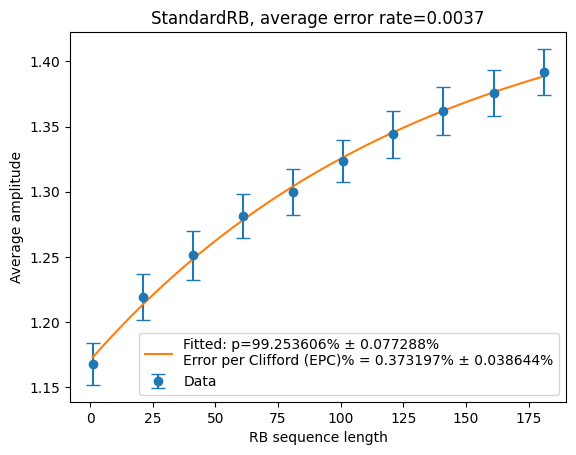

In [81]:
std_r_avg = np.abs(np.mean(rb_result, axis=1))
std_r_std = np.abs(np.std(rb_result, axis=1))

pOpt, pCov = fitrb(x, std_r_avg)

std_p_fit = pOpt[0]
std_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(std_p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {std_p_fit*100:.6f} ± {std_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(x, std_r_avg, yerr=std_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={std_p_fit*100:.6f}% ± {std_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
# plt.xscale('log')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'StandardRB, average error rate={rb_error(std_p_fit,2):.4f}')
# plt.title('InterleavedRB')

plt.legend()
plt.show()

## interleve

In [82]:
sxrb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        gate_char = "X/2"
        pulse_name_seq, total_clifford = interleaved_gate_sequence(i, gate_char=gate_char, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)
        run_cfg['gate_seq'] = full_sequence

        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, rounds=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))
    sxrb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 98.931854 ± 0.089981
Error per Clifford (EPC)% = 0.534073 ± 0.044991


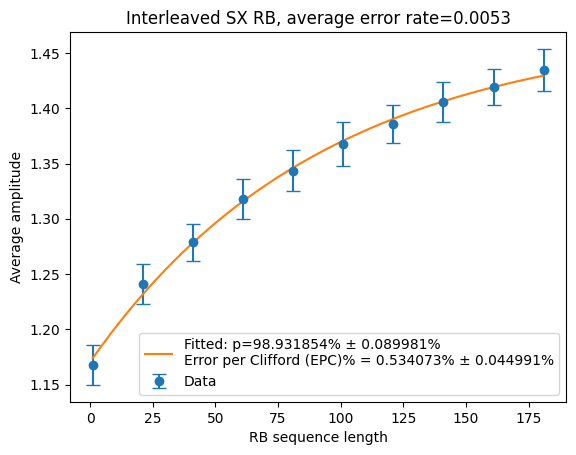

In [83]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sx_r_avg = np.abs(np.mean(sxrb_result, axis=1))
sx_r_std = np.abs(np.std(sxrb_result, axis=1))

pOpt, pCov = fitrb(x, sx_r_avg)

sx_p_fit = pOpt[0]
sx_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(sx_p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {sx_p_fit*100:.6f} ± {sx_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(x, sx_r_avg, yerr=sx_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={sx_p_fit*100:.6f}% ± {sx_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'Interleaved SX RB, average error rate={rb_error(sx_p_fit,2):.4f}')

plt.legend()
plt.show()

In [84]:
xrb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        gate_char = "X"
        pulse_name_seq, total_clifford = interleaved_gate_sequence(i, gate_char=gate_char, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)
        run_cfg['gate_seq'] = full_sequence

        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, rounds=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))
    xrb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 99.025669 ± 0.076171
Error per Clifford (EPC)% = 0.487165 ± 0.038085


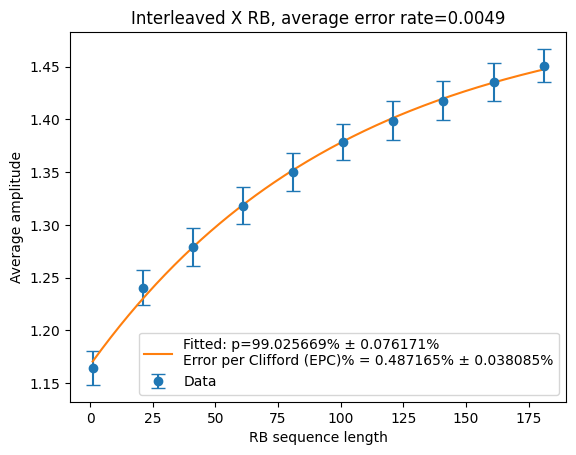

In [85]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
x_r_avg = np.abs(np.mean(xrb_result, axis=1))
x_r_std = np.abs(np.std(xrb_result, axis=1))

pOpt, pCov = fitrb(x, x_r_avg)

x_p_fit = pOpt[0]
x_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(x_p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {x_p_fit*100:.6f} ± {x_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)

plt.errorbar(x, x_r_avg, yerr=x_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={x_p_fit*100:.6f}% ± {x_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'Interleaved X RB, average error rate={rb_error(x_p_fit,2):.4f}')

plt.legend()
plt.show()

In [86]:
print('x/2 fidelity:', rb_gate_fidelity(std_p_fit, sx_p_fit, 2, std_p_fit_err, sx_p_fit_err))
print('x fidelity:',rb_gate_fidelity(std_p_fit, x_p_fit, 2, std_p_fit_err, x_p_fit_err))

x/2 fidelity: (0.9983791382834141, 0.005843073558276957)
x fidelity: (0.9988517441242237, 0.006315679399086671)


# RB qiskit

In [ ]:
class RB(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        cool1_ch = cfg['cool1_ch']
        cool2_ch = cfg['cool2_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][cool1_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'], mixer_freq=2000)
        else:
            self.declare_gen(ch=cool1_ch, nqz=cfg['nqz'])

        if soccfg['gens'][cool2_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'], mixer_freq=2000)
        else:
            self.declare_gen(ch=cool2_ch, nqz=cfg['nqz'])

        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_pulse(ch=cool1_ch, name="cool1",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool1'], 
                       phase= 0,
                       gain=cfg['cool1_gain'],
                      )
        self.add_pulse(ch=cool2_ch, name="cool2",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_cool2'], 
                       phase= 0,
                       gain=cfg['cool2_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            ## X pulse ##
            self.add_pulse(ch=qubit_ch, name="rx(pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="rx(-pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="rx(pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="rx(-pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=-cfg['pi2_gain'], 
                    )
            ## Y pulse ##
            self.add_pulse(ch=qubit_ch, name="ry(pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="ry(-pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="ry(pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="ry(-pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=-cfg['pi2_gain'], 
                    )


    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # Cooling process
        self.pulse(ch=cfg["cool1_ch"], name="cool1", t=0)
        self.pulse(ch=cfg["cool2_ch"], name="cool2", t=0)
        self.delay_auto(0.5)
        for i in self.cfg['gate_seq']:
            if i=='barrier':
                pass
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name=f"{i}", t=0) 
                self.delay_auto(0.0)

        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

from qiskit import transpile
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit.circuit.library import XGate, SXGate
from qiskit import qasm3, QuantumCircuit, QuantumRegister, ClassicalRegister
import re

xdata = np.unique(np.logspace(0.4, 2, 10).astype(int))

ydata_list = np.arange(100)

pyavg = 50




std_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    exp = StandardRB([0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    std_rblist_len.append(rblist)


x_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    exp = InterleavedRB(XGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    x_rblist_len.append(rblist)

sx_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    # exp = StandardRB([0], [i], num_samples=len(ydata_list))
    exp = InterleavedRB(SXGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    sx_rblist_len.append(rblist)


depth:   0%|          | 0/10 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

...

reps:   0%|          | 0/100 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

reps:   0%|          | 0/100 [00:00<?, ?it/s]

Fitted std: p = 98.10 ± 0.05
Error per Clifford (EPC)% = 0.95 ± 0.03


<Figure size 800x600 with 0 Axes>

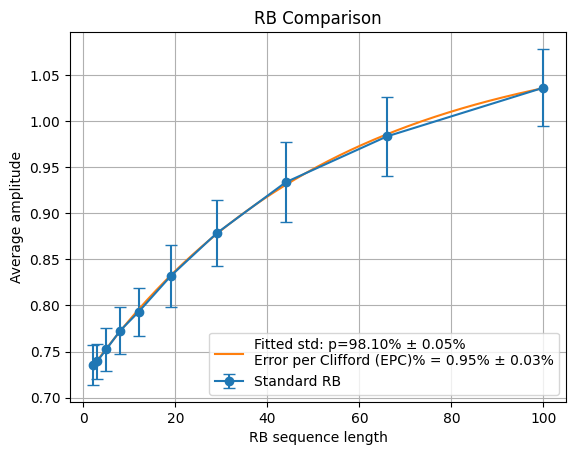

Fitted x: p = 97.49 ± 0.23
Error per Clifford (EPC)% = 1.25 ± 0.11


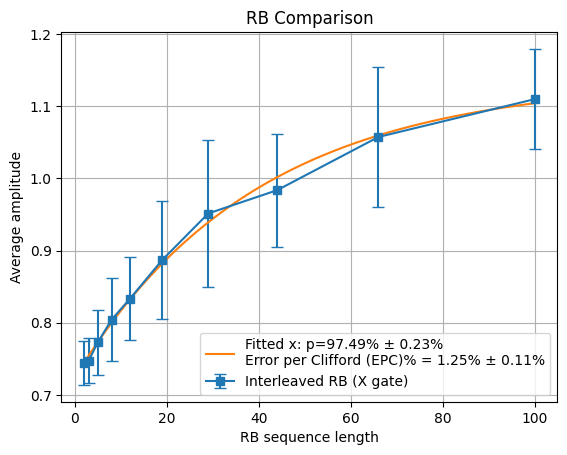

Fitted sx: p = 97.96 ± 0.10
Error per Clifford (EPC)% = 1.02 ± 0.05


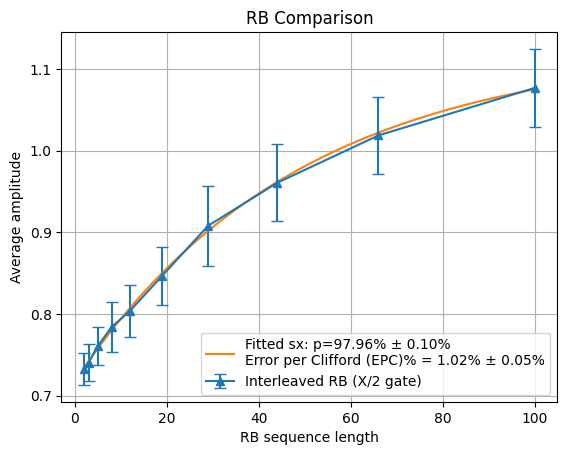

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
r_avg = np.abs(np.mean(std_rblist_len, axis=1))
r_std = np.abs(np.std(std_rblist_len, axis=1))

xrb_avg = np.abs(np.mean(x_rblist_len, axis=1))
xrb_err = np.abs(np.std(x_rblist_len, axis=1))

sxrb_avg = np.abs(np.mean(sx_rblist_len, axis=1))
sxrb_err = np.abs(np.std(sx_rblist_len, axis=1))

sequence_len = xdata


plt.figure(figsize=(8,6))
plt.figure()
pOpt, pCov = fitrb(sequence_len, r_avg)
std_p_fit = pOpt[0]
std_p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(std_p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted std: p = {std_p_fit*100:.2f} ± {std_p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, r_avg, yerr=r_std, fmt='o-', capsize=4, label='Standard RB')
plt.plot(xfit, yfit, '-', label=f'Fitted std: p={std_p_fit*100:.2f}% ± {std_p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
pOpt, pCov = fitrb(sequence_len, xrb_avg)
x_p_fit = pOpt[0]
x_p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(x_p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted x: p = {x_p_fit*100:.2f} ± {x_p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, xrb_avg, yerr=xrb_err, fmt='s-', capsize=4, label='Interleaved RB (X gate)')
plt.plot(xfit, yfit, '-', label=f'Fitted x: p={x_p_fit*100:.2f}% ± {x_p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
pOpt, pCov = fitrb(sequence_len, sxrb_avg)
sx_p_fit = pOpt[0]
sx_p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(sx_p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted sx: p = {sx_p_fit*100:.2f} ± {sx_p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, sxrb_avg, yerr=sxrb_err, fmt='^-', capsize=4, label='Interleaved RB (X/2 gate)')
plt.plot(xfit, yfit, '-', label=f'Fitted sx: p={sx_p_fit*100:.2f}% ± {sx_p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')

plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
print(rb_gate_fidelity(std_p_fit, sx_p_fit, 2, std_p_fit_err, sx_p_fit_err))
print(rb_gate_fidelity(std_p_fit, x_p_fit, 2, std_p_fit_err, x_p_fit_err))

(0.996742528336252, 0.010868869853752017)
(0.9954589272110584, 0.009585268728558471)


In [ ]:
class Sweep2DProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=2)
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)

        self.add_loop("loop1", self.cfg["steps1"]) # outer loop
        self.add_loop("loop2", self.cfg["steps2"]) # inner loop

        self.add_pulse(ch=gen_ch, name="myconst", ro_ch=ro_ch,
                       style="const",
                       length=cfg['pulse_len'],
                       freq=cfg['freq'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['pulse_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['gen_ch'], name="myconst", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# We will sweep over the gain in both loop levels
config = {
    ## Sweep Params: ##
    'steps1': 100,
    'steps2': 50,
    ## Channel Params. ##
    'gen_ch': 0,
    'ro_ch': 0,
    ## Pulse Params. ##
    'freq': 4000, # [MHz]
    'pulse_len': 0.1, # [us]
    'pulse_phase': 0, # [deg]
    # initial value 0.4, sweep by 0.5 in loop1 and by 0.1 in loop2, in other words:
    # the very first shot is 0.4
    # the first loop2 sweep runs from 0.4 to 0.5
    # the last loop2 sweep runs from 0.9 to 1.0
    'pulse_gain': 0.4 + QickSpan("loop1", 0.5) + QickSpan("loop2", 0.1), # [DAC units]
    ## Readout Params. ##
    'trig_time': 0.35, # [us]
    'ro_len': 0.3, # [us]
     }

prog = Sweep2DProgram(soccfg, reps=100, final_delay=0.5, cfg=config)

iq_list = prog.acquire(soc, soft_avgs=100, progress=True)
t = prog.get_time_axis(ro_index=0)

  0%|          | 0/100 [00:00<?, ?it/s]

RuntimeError: exception in readout loop